---
---

## CS-4063: Natural Language Processing

# **Assignment 03: Transformer-based Review Understanding with RAG Enhanced Explanation Generation**


**Fatima Tu Zahra**

**23i-2616**

**BDS-6B**

**Spring-2026**

<!-- https://github.com/fatima-1206/i23-2616-NLP-Assignment2 -->

[![GitHub](https://img.shields.io/badge/GitHub-View%20Repository-blue?logo=github&style=flat-square)](https://github.com/fatima-1206/i232616-NLP-Assignment3)

---
---

# Imports

In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re
import pickle
import os
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# Set random seeds
np.random.seed(42)
torch.manual_seed(42)




In this assignment, you will build a three-stage NLP system that first extracts structured  information from text, retrieves relevant examples from the dataset, and then generates grounded  natural language explanations. The three stages — encoding, retrieval, and generation — are  implemented in Parts A, B, and C respectively, and must work together as a coherent pipeline. 



## Restrictions — Read Before You Start 

Both the encoder-only and decoder-only Transformer models must be implemented entirely  from scratch. You are not allowed to use any pretrained models such as BERT, GPT, T5, or  any library that abstracts away the internal Transformer implementation.The following built ins are not allowed: nn.Transformer, nn.MultiheadAttention, nn.TransformerEncoder.








### Dataset Description 

You will use the Amazon Reviews dataset, available at: 

https://nijianmo.github.io/amazon/index.html 

You are required to construct your own dataset subset. To ensure diversity, you must select  reviews from at least three different product categories, including approximately ten to fifteen  thousand reviews per category, resulting in a final dataset of between thirty thousand and forty five thousand samples. Each sample must include the review text and its corresponding star rating  on a scale of one to five. 

You must divide your dataset into training, validation, and testing sets using a 70%, 15%, and  15% split respectively. You are fully responsible for preparing the dataset and ensuring it is  suitable for training. 


In [3]:
df_beauty = pd.read_json('Dataset/beauty.json.gz', lines=True, compression='gzip')
df_beauty = df_beauty.sample(n=10000, random_state=42)
df_home = pd.read_json('Dataset/home.json.gz', lines=True, compression='gzip')
df_home = df_home.sample(n=10000, random_state=42)
df_electronics = pd.read_json('Dataset/electronics.json.gz', lines=True, compression='gzip')
df_electronics = df_electronics.sample(n=10000, random_state=42)

In [4]:
df_beauty

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
186406,APP35M28G2U51,B00G3HM9ZI,M. Lafferman,"[2, 4]","I don't get calluses per say on my feet, but I...",3,Nothing Special,1396310400,"04 1, 2014"
139161,A2DY1GY47MWU6I,B006QO4BRM,brina,"[0, 0]",light works good lights are not hard to put in...,4,regular,1359417600,"01 29, 2013"
12978,ARVD852Y0IZVL,B0009MHJS0,SimplyChic Momma,"[11, 11]",&lt;UPDATED REVIEW>After using this for a few ...,1,"Way too yellow, not 100% shea butter",1344211200,"08 6, 2012"
101036,AV283XHFJEGLZ,B0045JAPYI,Paddows,"[1, 1]",This is probably a waste of money. This is sim...,3,Make your own,1359244800,"01 27, 2013"
4380,A20GIKYR0OT9KY,B0000Y3FRG,R. Carraway,"[2, 2]",Smells great! Skin is soft and smooth with mat...,5,&lt;MissVirgo>,1317427200,"10 1, 2011"
...,...,...,...,...,...,...,...,...,...
123768,AFEYHFH2GH0QZ,B005F2AD3W,AJ,"[0, 0]","After two months, I honestly couldn't spot a s...",1,Couldn't spot a single difference or improveme...,1362009600,"02 28, 2013"
165511,A3S3R88HA0HZG3,B00A0IWRUI,PT Cruiser,"[0, 0]",I'm adding this to my list of favorite Suave c...,5,Leaves my hair tangle-free,1363132800,"03 13, 2013"
62923,A1XLIWO29Y9P8G,B001OMI93S,TammyR,"[0, 0]",For me this is not meant for a night cream. On...,4,Great for daytime cream.,1355788800,"12 18, 2012"
118697,AH07HWB1RLIPN,B0050PWTMM,Ashley Dufault,"[1, 1]",I have mixed opinions on this product. Having...,3,Quick order fulfillment for an unimpressive pr...,1379376000,"09 17, 2013"


In [5]:
df_electronics

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
981956,A3E3VF85DAW0FU,B004M8S12A,RedRover,"[57, 67]","Well, after trying out some Box Towers....that...",5,Best in Class,1307404800,"06 7, 2011"
615465,A15X0XCY1EKJHL,B002KANXBG,"James Stitley ""Jim Stitley""","[16, 16]",I ordered one for my wife and one for me. Afte...,5,S 70 Review,1261612800,"12 24, 2009"
1060045,A393R1LK2A468F,B0050I1PHO,nelson 8A,"[3, 7]",muy buen producto... a full en juegos fHD.... ...,5,nice,1314576000,"08 29, 2011"
248321,AEL8SXIP0GNYU,B000JNA4LS,Scott,"[0, 0]",The sound quality of this unit is phenomenal. ...,5,Crushes Bose SoundDock II,1235433600,"02 24, 2009"
1498033,A3O2Z9D0Y0G5XQ,B009VV56TY,Reese,"[0, 0]",It is good on keeping your cpu cool also down'...,4,it does what it say.,1401148800,"05 27, 2014"
...,...,...,...,...,...,...,...,...,...
953691,A14EPTYN50XSZV,B004H8FNBC,Someone Else,"[1, 1]",If you don't buy or use a lot of electronic eq...,3,"Middle of the Road. Not Bad, But Not Great.",1342051200,"07 12, 2012"
957266,A1F94PADD3DUMV,B004HKIIF8,Allen Stegall,"[0, 0]",I love this tablet and use it nearly every day...,4,Great tablet,1385596800,"11 28, 2013"
541811,A27GREXNJBQP02,B001UGMTKC,amazoncustomer,"[1, 7]",If you just use your phone for music and talki...,2,IF YOU WANT TO GET IN AN ACCIDENT...,1311379200,"07 23, 2011"
301805,A3RX5CXBGLG53N,B000RFPBQQ,IndianaJohn,"[3, 3]",Range is vastly expanded inside and outside my...,5,Dell D630 WiFi adapter replacement,1325721600,"01 5, 2012"


In [6]:
df_home

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
318848,A3HNCGMJANCQTH,B002M3SP4Q,NaN,"[0, 0]",This Hamper looks really good and is bigger th...,5,Great Hamper!,1357516800,"01 7, 2013"
545423,A2TZWI7MAXGKI5,B00HZ8MY3G,"Alexander White ""RN""","[3, 3]","I needed a good zester, and although I already...",3,DISSAPOINTED,1395446400,"03 22, 2014"
335322,A2M1N5J8KL17IJ,B002X5RZAI,"A. Thompson ""yellow_apple30""","[2, 2]",I like this a lot for use in my kitchen and ba...,4,Great for the Price,1297123200,"02 8, 2011"
222055,A2YTL64ZTEW3IT,B000X7GF40,Amazon Customer,"[0, 0]",I am a big fan of lattes... and at $3 or $4 a ...,5,Love this,1359244800,"01 27, 2013"
317361,A2G0JRKYWJHE4W,B002L0WMNU,Joanna J Blevins,"[0, 0]","I haven't spilled anything on it, but I'm sure...",3,Good for the price,1388966400,"01 6, 2014"
...,...,...,...,...,...,...,...,...,...
540670,ASBSPNY56QD1X,B00GBCBMAI,SJ,"[1, 1]",I have never purchased a food scale before so ...,4,Does what is says,1403654400,"06 25, 2014"
468728,A2EGK0YRDF4ZZB,B0071NI8XK,"Sarah ""Eat Dessert First""","[0, 0]",I first saw the Kuhn Rikon Kochblume at Sur La...,4,"Stops spills, but the design could use some im...",1368576000,"05 15, 2013"
254327,AVFDFNRFLXGKG,B001BS5W1W,Dennis Atwell,"[0, 0]",Not a lot to say about these hooks they do the...,5,Good product,1389398400,"01 11, 2014"
191200,A2IDHA68MY29FH,B000OWSHLI,Davilyn Eversz,"[17, 17]",I was pleasantly surprised to see these aren't...,5,"Good price, well made",1278374400,"07 6, 2010"


In [7]:
# combining the three dataframes into one
df = pd.concat([df_beauty, df_electronics, df_home], ignore_index=True)
df

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime
0,APP35M28G2U51,B00G3HM9ZI,M. Lafferman,"[2, 4]","I don't get calluses per say on my feet, but I...",3,Nothing Special,1396310400,"04 1, 2014"
1,A2DY1GY47MWU6I,B006QO4BRM,brina,"[0, 0]",light works good lights are not hard to put in...,4,regular,1359417600,"01 29, 2013"
2,ARVD852Y0IZVL,B0009MHJS0,SimplyChic Momma,"[11, 11]",&lt;UPDATED REVIEW>After using this for a few ...,1,"Way too yellow, not 100% shea butter",1344211200,"08 6, 2012"
3,AV283XHFJEGLZ,B0045JAPYI,Paddows,"[1, 1]",This is probably a waste of money. This is sim...,3,Make your own,1359244800,"01 27, 2013"
4,A20GIKYR0OT9KY,B0000Y3FRG,R. Carraway,"[2, 2]",Smells great! Skin is soft and smooth with mat...,5,&lt;MissVirgo>,1317427200,"10 1, 2011"
...,...,...,...,...,...,...,...,...,...
29995,ASBSPNY56QD1X,B00GBCBMAI,SJ,"[1, 1]",I have never purchased a food scale before so ...,4,Does what is says,1403654400,"06 25, 2014"
29996,A2EGK0YRDF4ZZB,B0071NI8XK,"Sarah ""Eat Dessert First""","[0, 0]",I first saw the Kuhn Rikon Kochblume at Sur La...,4,"Stops spills, but the design could use some im...",1368576000,"05 15, 2013"
29997,AVFDFNRFLXGKG,B001BS5W1W,Dennis Atwell,"[0, 0]",Not a lot to say about these hooks they do the...,5,Good product,1389398400,"01 11, 2014"
29998,A2IDHA68MY29FH,B000OWSHLI,Davilyn Eversz,"[17, 17]",I was pleasantly surprised to see these aren't...,5,"Good price, well made",1278374400,"07 6, 2010"


In [8]:
df.columns

Index(['reviewerID', 'asin', 'reviewerName', 'helpful', 'reviewText',
       'overall', 'summary', 'unixReviewTime', 'reviewTime'],
      dtype='object')

In [30]:
df.to_csv("df.csv", index=False)

In [3]:
!rm Dataset.zip
!zip Dataset.zip df.csv

  adding: df.csv (deflated 59%)


In [4]:
!rm df.csv
!unzip Dataset.zip

Archive:  Dataset.zip
  inflating: df.csv                  


In [5]:
df = pd.read_csv("df.csv")  
df

,reviewerID,asin,reviewerName,helpful,reviewText,overall,summary,unixReviewTime,reviewTime,text_length,sentiment_label,length_category
0,APP35M28G2U51,B00G3HM9ZI,M. Lafferman,"[2, 4]","I don't get calluses per say on my feet, but I...",3,Nothing Special,1396310400,"04 1, 2014",182,1,1
1,A2DY1GY47MWU6I,B006QO4BRM,brina,"[0, 0]",light works good lights are not hard to put in...,4,regular,1359417600,"01 29, 2013",21,2,0
2,ARVD852Y0IZVL,B0009MHJS0,SimplyChic Momma,"[11, 11]",&lt;UPDATED REVIEW>After using this for a few ...,1,"Way too yellow, not 100% shea butter",1344211200,"08 6, 2012",166,0,1
3,AV283XHFJEGLZ,B0045JAPYI,Paddows,"[1, 1]",This is probably a waste of money. This is sim...,3,Make your own,1359244800,"01 27, 2013",34,1,0
4,A20GIKYR0OT9KY,B0000Y3FRG,R. Carraway,"[2, 2]",Smells great! Skin is soft and smooth with mat...,5,&lt;MissVirgo>,1317427200,"10 1, 2011",31,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...
29995,ASBSPNY56QD1X,B00GBCBMAI,SJ,"[1, 1]",I have never purchased a food scale before so ...,4,Does what is says,1403654400,"06 25, 2014",83,2,0
29996,A2EGK0YRDF4ZZB,B0071NI8XK,"Sarah ""Eat Dessert First""","[0, 0]",I first saw the Kuhn Rikon Kochblume at Sur La...,4,"Stops spills, but the design could use some im...",1368576000,"05 15, 2013",399,2,2
29997,AVFDFNRFLXGKG,B001BS5W1W,Dennis Atwell,"[0, 0]",Not a lot to say about these hooks they do the...,5,Good product,1389398400,"01 11, 2014",21,2,0
29998,A2IDHA68MY29FH,B000OWSHLI,Davilyn Eversz,"[17, 17]",I was pleasantly surprised to see these aren't...,5,"Good price, well made",1278374400,"07 6, 2010",21,2,0


# **PART 0: PREPROCESSING PIPELINE**


#### Preprocessing 

All preprocessing must be implemented by you using the techniques covered in previous lectures.  Your pipeline should include text cleaning where necessary, tokenization, vocabulary construction using only the training data, conversion of tokens to numerical indices, and the application of  padding and truncation with a fixed maximum sequence length of your choosing. Every step of  your preprocessing pipeline must be clearly explained in your report. 


## 0 Exploratory Data Analysis (EDA)
Analyze review text properties to inform preprocessing decisions.


Missing values:
reviewerID           0
asin                 0
reviewerName       313
helpful              0
reviewText          16
overall              0
summary              0
unixReviewTime       0
reviewTime           0
text_length          0
sentiment_label      0
length_category      0
dtype: int64

Review Text Length Statistics:
count    30000.000000
mean       101.586233
std        134.580214
min          1.000000
25%         33.000000
50%         61.000000
75%        119.000000
max       5610.000000
Name: text_length, dtype: float64

Label (Rating) Distribution:
overall
1     1706
2     1510
3     2884
4     5834
5    18066
Name: count, dtype: int64


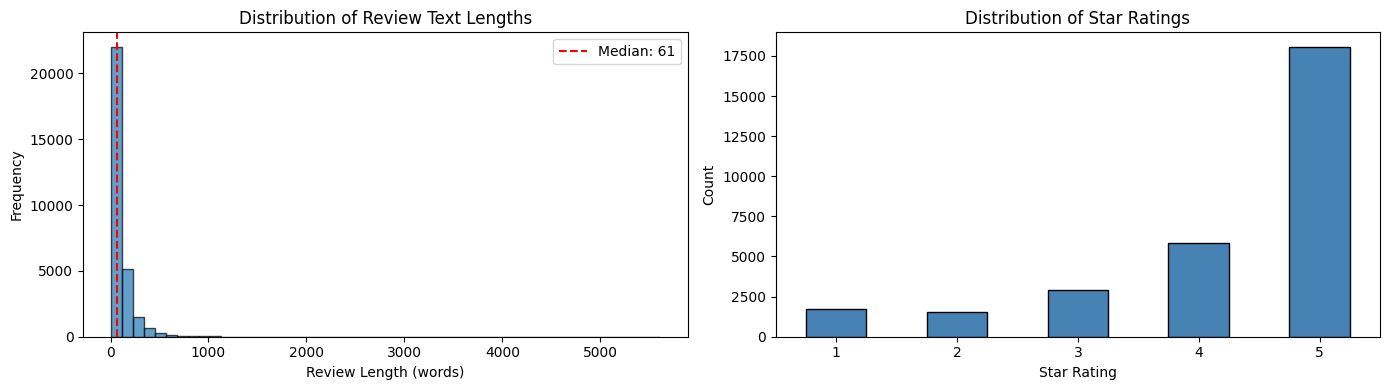


Dataset shape: (30000, 12)
Total samples: 30000
Average review length: 101.59 words
Median review length: 61.00 words
Max review length: 5610 words

Selected max_seq_length: 256 (covers 92.6% of data)


In [6]:
# Create results directory
os.makedirs('results', exist_ok=True)

# Check for missing values
print(f"\nMissing values:\n{df.isnull().sum()}")

# Analyze review text lengths
df['text_length'] = df['reviewText'].apply(lambda x: len(str(x).split()))
print(f"\nReview Text Length Statistics:")
print(df['text_length'].describe())

# Label distribution
print(f"\nLabel (Rating) Distribution:")
label_dist = df['overall'].value_counts().sort_index()
print(label_dist)

# Visualize distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Text length distribution
axes[0].hist(df['text_length'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Review Length (words)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Review Text Lengths')
axes[0].axvline(df['text_length'].median(), color='r', linestyle='--', label=f'Median: {df["text_length"].median():.0f}')
axes[0].legend()

# Rating distribution
label_dist.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_xlabel('Star Rating')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of Star Ratings')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('results/01_eda_distributions.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nDataset shape: {df.shape}")
print(f"Total samples: {len(df)}")
print(f"Average review length: {df['text_length'].mean():.2f} words")
print(f"Median review length: {df['text_length'].median():.2f} words")
print(f"Max review length: {df['text_length'].max()} words")
print(f"\nSelected max_seq_length: 256 (covers {(df['text_length'] <= 256).sum() / len(df) * 100:.1f}% of data)")

## 0.1 Data Preparation: Sentiment Mapping & Train/Val/Test Split

In [7]:
# Sentiment mapping: 1-2 → Negative (0), 3 → Neutral (1), 4-5 → Positive (2)
def map_sentiment(rating):
    if rating in [1, 2]:
        return 0  # Negative
    elif rating == 3:
        return 1  # Neutral
    else:  # 4, 5
        return 2  # Positive

df['sentiment_label'] = df['overall'].apply(map_sentiment)

print("\nSentiment Label Distribution (Mapped):")
print(df['sentiment_label'].value_counts().sort_index())
print(f"Negative (1-2 stars): {(df['sentiment_label'] == 0).sum()}")
print(f"Neutral (3 stars): {(df['sentiment_label'] == 1).sum()}")
print(f"Positive (4-5 stars): {(df['sentiment_label'] == 2).sum()}")

# Define derived feature: Review Length Category
# Short (0-100 words), Medium (101-250 words), Long (251+ words)
def get_length_category(length):
    if length <= 100:
        return 0  # Short
    elif length <= 250:
        return 1  # Medium
    else:
        return 2  # Long

df['length_category'] = df['text_length'].apply(get_length_category)

print("\nDerived Feature - Length Category Distribution:")
print("Short (0-100 words):", (df['length_category'] == 0).sum())
print("Medium (101-250 words):", (df['length_category'] == 1).sum())
print("Long (251+ words):", (df['length_category'] == 2).sum())

# Prepare data for splitting
X = df['reviewText'].values
y_sentiment = df['sentiment_label'].values
y_length = df['length_category'].values

# Train/Val/Test Split: 70/15/15 with stratification by sentiment
X_train, X_temp, y_sent_train, y_sent_temp, y_len_train, y_len_temp = train_test_split(
    X, y_sentiment, y_length, 
    test_size=0.30, 
    random_state=42, 
    stratify=y_sentiment
)

X_val, X_test, y_sent_val, y_sent_test, y_len_val, y_len_test = train_test_split(
    X_temp, y_sent_temp, y_len_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_sent_temp
)

print(f"Training set: {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"Total: {len(X_train) + len(X_val) + len(X_test)} samples")

# Verify stratification
print(f"\nSentiment distribution in train: {np.bincount(y_sent_train)}")
print(f"Sentiment distribution in val: {np.bincount(y_sent_val)}")
print(f"Sentiment distribution in test: {np.bincount(y_sent_test)}")


Sentiment Label Distribution (Mapped):
sentiment_label
0     3216
1     2884
2    23900
Name: count, dtype: int64
Negative (1-2 stars): 3216
Neutral (3 stars): 2884
Positive (4-5 stars): 23900

Derived Feature - Length Category Distribution:
Short (0-100 words): 20782
Medium (101-250 words): 6905
Long (251+ words): 2313
Training set: 21000 samples
Validation set: 4500 samples
Test set: 4500 samples
Total: 30000 samples

Sentiment distribution in train: [ 2251  2019 16730]
Sentiment distribution in val: [ 482  433 3585]
Sentiment distribution in test: [ 483  432 3585]


## 0.2 Text Cleaning

In [8]:
def clean_text(text):
    text = str(text).lower()
    
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove HTML entities (e.g., &amp;)
    text = re.sub(r'&\w+;', '', text)
    
    # Remove extra whitespace and newlines
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# Apply cleaning to all splits
print("Cleaning text...")
X_train_clean = np.array([clean_text(text) for text in tqdm(X_train, desc="Cleaning train")])
X_val_clean = np.array([clean_text(text) for text in tqdm(X_val, desc="Cleaning val")])
X_test_clean = np.array([clean_text(text) for text in tqdm(X_test, desc="Cleaning test")])

print("\nSample cleaned reviews:")
for i in range(3):
    print(f"\nOriginal: {X_train[i][:100]}...")
    print(f"Cleaned: {X_train_clean[i][:100]}...")

Cleaning text...


Cleaning test: 100%|██████████| 4500/4500 [00:00<00:00, 23038.54it/s]



Sample cleaned reviews:

Original: I used this for the first time today, and I'm really impressed. I have extremely thick, coarse, curl...
Cleaned: i used this for the first time today, and i'm really impressed. i have extremely thick, coarse, curl...

Original: This is a very nice shower curtain and the price was right. Fits my tub perfectly and doesn't bunch ...
Cleaned: this is a very nice shower curtain and the price was right. fits my tub perfectly and doesn't bunch ...

Original: I have been a user of Seventh Generation products for over a year. In the case of this company, they...
Cleaned: i have been a user of seventh generation products for over a year. in the case of this company, they...


## 0.3 Tokenization

In [9]:
def tokenize_text(text):
    # Split by whitespace
    tokens = text.split()
    
    # Separate final punctuation if present
    processed_tokens = []
    for token in tokens:
        if token[-1] in '.!?,;:':
            processed_tokens.extend([token[:-1], token[-1]])
        else:
            processed_tokens.append(token)
    
    return processed_tokens

# Tokenize training data (vocabulary will be built from this only)
print("Tokenizing text...")
X_train_tokens = [tokenize_text(text) for text in tqdm(X_train_clean, desc="Tokenizing train")]

print("\nSample tokenized reviews:")
for i in range(2):
    print(f"Tokens ({len(X_train_tokens[i])} tokens): {X_train_tokens[i][:30]}")

Tokenizing text...


Tokenizing train: 100%|██████████| 21000/21000 [00:01<00:00, 13727.09it/s]


Sample tokenized reviews:
Tokens (304 tokens): ['i', 'used', 'this', 'for', 'the', 'first', 'time', 'today', ',', 'and', "i'm", 'really', 'impressed', '.', 'i', 'have', 'extremely', 'thick', ',', 'coarse', ',', 'curly/frizzy', 'hair', '.', "it's", 'not', 'fun', '.', 'i', 'clarified']
Tokens (23 tokens): ['this', 'is', 'a', 'very', 'nice', 'shower', 'curtain', 'and', 'the', 'price', 'was', 'right', '.', 'fits', 'my', 'tub', 'perfectly', 'and', "doesn't", 'bunch', 'up', 'weird', '.']


## 0.4 Vocabulary Construction (Training Data Only)

In [10]:
# Build vocabulary from training data only
print("Building vocabulary from training data...")

# Count token frequencies
token_counter = Counter()
for tokens in tqdm(X_train_tokens, desc="Counting frequencies"):
    token_counter.update(tokens)

print(f"\nTotal unique tokens in training data: {len(token_counter)}")

# Define special tokens
SPECIAL_TOKENS = {
    '[PAD]': 0,
    '[UNK]': 1,
    '[CLS]': 2,
    '[SEP]': 3,
}

# Keep most frequent tokens (vocab_size - reserved for special tokens)
VOCAB_SIZE = 10000
RESERVED_SIZE = len(SPECIAL_TOKENS)
NUM_REGULAR_TOKENS = VOCAB_SIZE - RESERVED_SIZE

# Get most common tokens
most_common_tokens = token_counter.most_common(NUM_REGULAR_TOKENS)

print(f"\nVocabulary configuration:")
print(f"  Total vocab size: {VOCAB_SIZE}")
print(f"  Special tokens: {RESERVED_SIZE}")
print(f"  Regular tokens: {NUM_REGULAR_TOKENS}")

# Build token-to-index and index-to-token mappings
token_to_idx = SPECIAL_TOKENS.copy()
idx_to_token = {v: k for k, v in SPECIAL_TOKENS.items()}

for idx, (token, freq) in enumerate(most_common_tokens):
    token_idx = idx + RESERVED_SIZE
    token_to_idx[token] = token_idx
    idx_to_token[token_idx] = token

print(f"\nFinal vocabulary size: {len(token_to_idx)}")
print(f"\nTop 20 most frequent tokens:")
for token, freq in most_common_tokens[:20]:
    print(f"  '{token}': {freq}")

# Save vocabulary
os.makedirs('results', exist_ok=True)
with open('results/vocab_token2idx.pkl', 'wb') as f:
    pickle.dump(token_to_idx, f)
with open('results/vocab_idx2token.pkl', 'wb') as f:
    pickle.dump(idx_to_token, f)

print("\nVocabulary saved to results/vocab_token2idx.pkl and results/vocab_idx2token.pkl")

Building vocabulary from training data...


Counting frequencies: 100%|██████████| 21000/21000 [00:00<00:00, 48998.22it/s]



Total unique tokens in training data: 78778

Vocabulary configuration:
  Total vocab size: 10000
  Special tokens: 4
  Regular tokens: 9996

Final vocabulary size: 10000

Top 20 most frequent tokens:
  '.': 108881
  'the': 100813
  ',': 76046
  'i': 65794
  'and': 60552
  'a': 55005
  'to': 54008
  'it': 52952
  'is': 34273
  'this': 31595
  'of': 30125
  'for': 27672
  'my': 25716
  'in': 21701
  'that': 20938
  'with': 19227
  'on': 17952
  'have': 16795
  'you': 16793
  'but': 16433

Vocabulary saved to results/vocab_token2idx.pkl and results/vocab_idx2token.pkl


## 0.5 Tokenize Validation & Test Sets

In [11]:
print("Tokenizing validation and test sets...")
X_val_tokens = [tokenize_text(text) for text in tqdm(X_val_clean, desc="Tokenizing val")]
X_test_tokens = [tokenize_text(text) for text in tqdm(X_test_clean, desc="Tokenizing test")]

print(f"Train tokens: {len(X_train_tokens)} reviews")
print(f"Val tokens: {len(X_val_tokens)} reviews")
print(f"Test tokens: {len(X_test_tokens)} reviews")

Tokenizing validation and test sets...


Tokenizing test: 100%|██████████| 4500/4500 [00:00<00:00, 10592.19it/s]

Train tokens: 21000 reviews
Val tokens: 4500 reviews
Test tokens: 4500 reviews


## 0.6 Token-to-Index Conversion & Padding/Truncation

In [12]:
# Hyperparameters for padding/truncation
MAX_SEQ_LENGTH = 256
PAD_IDX = token_to_idx['[PAD]']
UNK_IDX = token_to_idx['[UNK]']

def tokens_to_indices(tokens, token_to_idx, max_length=256, pad_idx=0, unk_idx=1):
    # Truncate if too long
    if len(tokens) > max_length:
        tokens = tokens[:max_length]
    
    # Convert tokens to indices (unknown tokens → [UNK])
    indices = []
    for token in tokens:
        if token in token_to_idx:
            indices.append(token_to_idx[token])
        else:
            indices.append(unk_idx)
    
    # Pad with [PAD] tokens
    if len(indices) < max_length:
        indices.extend([pad_idx] * (max_length - len(indices)))
    
    return np.array(indices, dtype=np.int64)

# Convert all splits
print("\nConverting tokens to indices and padding...")
X_train_indexed = np.array([
    tokens_to_indices(tokens, token_to_idx, MAX_SEQ_LENGTH, PAD_IDX, UNK_IDX)
    for tokens in tqdm(X_train_tokens, desc="Indexing train")
])

X_val_indexed = np.array([
    tokens_to_indices(tokens, token_to_idx, MAX_SEQ_LENGTH, PAD_IDX, UNK_IDX)
    for tokens in tqdm(X_val_tokens, desc="Indexing val")
])

X_test_indexed = np.array([
    tokens_to_indices(tokens, token_to_idx, MAX_SEQ_LENGTH, PAD_IDX, UNK_IDX)
    for tokens in tqdm(X_test_tokens, desc="Indexing test")
])

print(f"\nIndexed shapes:")
print(f"  X_train_indexed: {X_train_indexed.shape}")
print(f"  X_val_indexed: {X_val_indexed.shape}")
print(f"  X_test_indexed: {X_test_indexed.shape}")

# Verify all sequences have the same length
assert X_train_indexed.shape[1] == MAX_SEQ_LENGTH
assert X_val_indexed.shape[1] == MAX_SEQ_LENGTH
assert X_test_indexed.shape[1] == MAX_SEQ_LENGTH
print("✓ All sequences properly padded to max_seq_length")

# Display sample
print(f"\nSample indexed sequence (first 50 indices):")
print(X_train_indexed[0, :50])


Converting tokens to indices and padding...


Indexing test: 100%|██████████| 4500/4500 [00:00<00:00, 32836.69it/s]


Indexed shapes:
  X_train_indexed: (21000, 256)
  X_val_indexed: (4500, 256)
  X_test_indexed: (4500, 256)
✓ All sequences properly padded to max_seq_length

Sample indexed sequence (first 50 indices):
[   7   71   13   15    5  110   74  872    6    8   89   64  655    4
    7   21  551  326    6 2421    6    1   55    4   42   24  802    4
    7    1   16   55    6    8  938    1    1 6401 2013 5066    4    7
  354   11   20 2214    6    8   17    5]


## 0.7 Save Preprocessed Datasets

In [13]:
import json

# Create datasets as dictionaries for easy loading
train_dataset = {
    'input_ids': X_train_indexed,
    'sentiment_labels': y_sent_train,
    'length_labels': y_len_train,
    'original_text': X_train_clean,
    'tokens': X_train_tokens
}

val_dataset = {
    'input_ids': X_val_indexed,
    'sentiment_labels': y_sent_val,
    'length_labels': y_len_val,
    'original_text': X_val_clean,
    'tokens': X_val_tokens
}

test_dataset = {
    'input_ids': X_test_indexed,
    'sentiment_labels': y_sent_test,
    'length_labels': y_len_test,
    'original_text': X_test_clean,
    'tokens': X_test_tokens
}

# Save preprocessed datasets
print("Saving preprocessed datasets...")
os.makedirs('results', exist_ok=True)

with open('results/preprocessing_config.json', 'w') as f:
    json.dump({
        'vocab_size': VOCAB_SIZE,
        'max_seq_length': MAX_SEQ_LENGTH,
        'pad_idx': PAD_IDX,
        'unk_idx': UNK_IDX,
        'special_tokens': SPECIAL_TOKENS,
        'train_size': len(X_train_indexed),
        'val_size': len(X_val_indexed),
        'test_size': len(X_test_indexed),
    }, f, indent=2)

with open('results/preprocessed_train.pkl', 'wb') as f:
    pickle.dump(train_dataset, f)

with open('results/preprocessed_val.pkl', 'wb') as f:
    pickle.dump(val_dataset, f)

with open('results/preprocessed_test.pkl', 'wb') as f:
    pickle.dump(test_dataset, f)

print("\nSaved files:")
print("  ✓ results/preprocessing_config.json")
print("  ✓ results/preprocessed_train.pkl")
print("  ✓ results/preprocessed_val.pkl")
print("  ✓ results/preprocessed_test.pkl")
print("  ✓ results/vocab_token2idx.pkl")
print("  ✓ results/vocab_idx2token.pkl")

print("\nDataset Statistics:")
print(f"  Training set: {len(train_dataset['input_ids'])} samples")
print(f"  Validation set: {len(val_dataset['input_ids'])} samples")
print(f"  Test set: {len(test_dataset['input_ids'])} samples")
print(f"  Total: {len(train_dataset['input_ids']) + len(val_dataset['input_ids']) + len(test_dataset['input_ids'])} samples")

print("\nPreprocessing Configuration:")
print(f"  Vocabulary size: {VOCAB_SIZE}")
print(f"  Max sequence length: {MAX_SEQ_LENGTH}")
print(f"  Special tokens: {SPECIAL_TOKENS}")

print("\nLabel Distribution (Training Set):")
print(f"  Negative (0): {(y_sent_train == 0).sum()}")
print(f"  Neutral (1): {(y_sent_train == 1).sum()}")
print(f"  Positive (2): {(y_sent_train == 2).sum()}")

Saving preprocessed datasets...

Saved files:
  ✓ results/preprocessing_config.json
  ✓ results/preprocessed_train.pkl
  ✓ results/preprocessed_val.pkl
  ✓ results/preprocessed_test.pkl
  ✓ results/vocab_token2idx.pkl
  ✓ results/vocab_idx2token.pkl

Dataset Statistics:
  Training set: 21000 samples
  Validation set: 4500 samples
  Test set: 4500 samples
  Total: 30000 samples

Preprocessing Configuration:
  Vocabulary size: 10000
  Max sequence length: 256
  Special tokens: {'[PAD]': 0, '[UNK]': 1, '[CLS]': 2, '[SEP]': 3}

Label Distribution (Training Set):
  Negative (0): 2251
  Neutral (1): 2019
  Positive (2): 16730



## Part A Encoder Model for Understanding [25 Marks] 

In this part, you will implement an encoder-only Transformer model that performs multi-task  learning on the Amazon Reviews dataset. The model must jointly learn to classify the sentiment  of a review and predict a second derived feature that you define yourself. 

The sentiment classification must use a three-class formulation: ratings 1–2 are mapped to  Negative, rating 3 to Neutral, and ratings 4–5 to Positive. For the second task, you are free to  define any meaningful property of a review that can be predicted from the text alone. Your choice  must be clearly motivated and documented in your report. 

The encoder must produce three outputs for each review: a predicted sentiment label, a predicted  value for your derived feature, and a fixed-dimensional vector representation of the review. This  vector representation will be used as the basis for retrieval in ## Part B and must be saved to disk  after training. 

You must train the model end-to-end with a suitable combined loss. Your training pipeline must  produce learning curves and evaluation metrics for both tasks on the held-out test set. All design  choices regarding architecture, training procedure, and loss formulation are your own  responsibility. 


### Input representation :

Reviews are correctly represented as numerical  sequences; vocabulary built  from training data only


In [14]:
import math
from torch.utils.data import Dataset, DataLoader

# Device + hyperparameters
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
D_MODEL = 256
MAX_LEN = MAX_SEQ_LENGTH
NUM_CLASSES_SENT = 3
NUM_CLASSES_LEN = 3
BATCH_SIZE = 64
print(f"Using device: {DEVICE}")

# Make sure output directories exist
os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)

class ReviewDataset(Dataset):
    def __init__(self, input_ids, sentiment_labels, length_labels):
        self.input_ids = torch.tensor(input_ids, dtype=torch.long)
        self.sentiment_labels = torch.tensor(sentiment_labels, dtype=torch.long)
        self.length_labels = torch.tensor(length_labels, dtype=torch.long)

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return {
            'input_ids': self.input_ids[idx],
            'sentiment_label': self.sentiment_labels[idx],
            'length_label': self.length_labels[idx],
        }

train_ds = ReviewDataset(
    train_dataset['input_ids'],
    train_dataset['sentiment_labels'],
    train_dataset['length_labels'],
)
val_ds = ReviewDataset(
    val_dataset['input_ids'],
    val_dataset['sentiment_labels'],
    val_dataset['length_labels'],
)
test_ds = ReviewDataset(
    test_dataset['input_ids'],
    test_dataset['sentiment_labels'],
    test_dataset['length_labels'],
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

# Input representation: token embeddings + sinusoidal positional encodings
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len, :]

class InputRepresentation(nn.Module):
    def __init__(self, vocab_size, d_model, max_len, pad_idx, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.positional_encoding = PositionalEncoding(d_model, max_len=max_len)
        self.dropout = nn.Dropout(dropout)

    def forward(self, input_ids):
        x = self.token_embedding(input_ids) * math.sqrt(self.d_model)
        x = self.positional_encoding(x)
        return self.dropout(x)

input_repr = InputRepresentation(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    max_len=MAX_LEN,
    pad_idx=PAD_IDX,
    dropout=0.1,
).to(DEVICE)

batch = next(iter(train_loader))
batch_ids = batch['input_ids'].to(DEVICE)
embedded = input_repr(batch_ids)
print('Input ids shape:', batch_ids.shape)
print('Embedded shape:', embedded.shape)



Using device: cpu
Input ids shape: torch.Size([64, 256])
Embedded shape: torch.Size([64, 256, 256])



### Attention mechanism :

Attention is correctly  implemented; queries, keys  and values produce  meaningful alignments


In [15]:
class ScaledDotProductAttention(nn.Module):
    def __init__(self, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

    def forward(self, q, k, v, mask=None):
        # q, k, v: [B, H, L, D_h]
        d_k = q.size(-1)
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)

        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))

        attn_weights = torch.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)
        context = torch.matmul(attn_weights, v)
        return context, attn_weights




### Multi-head configuration 

Multiple attention heads  operate independently and  their outputs are correctly  combined


In [16]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0, 'd_model must be divisible by num_heads'
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

        self.attn = ScaledDotProductAttention(dropout=dropout)
        self.dropout = nn.Dropout(dropout)

    def split_heads(self, x):
        # [B, L, D] -> [B, H, L, D_h]
        B, L, _ = x.size()
        x = x.view(B, L, self.num_heads, self.head_dim)
        return x.transpose(1, 2)

    def combine_heads(self, x):
        # [B, H, L, D_h] -> [B, L, D]
        B, H, L, D_h = x.size()
        x = x.transpose(1, 2).contiguous()
        return x.view(B, L, H * D_h)

    def forward(self, x, mask=None):
        q = self.split_heads(self.q_proj(x))
        k = self.split_heads(self.k_proj(x))
        v = self.split_heads(self.v_proj(x))

        context, attn_weights = self.attn(q, k, v, mask=mask)
        out = self.combine_heads(context)
        out = self.out_proj(out)
        return self.dropout(out), attn_weights



### Encoder block design 

Complete encoder block with  normalisation, feed-forward  sub-layer, and residual connections


In [17]:
class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, ff_dim, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, ff_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(ff_dim, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

class EncoderBlock(nn.Module):
    def __init__(self, d_model, num_heads, ff_dim, dropout=0.1):
        super().__init__()
        self.mha = MultiHeadSelfAttention(d_model, num_heads, dropout)
        self.ffn = PositionwiseFeedForward(d_model, ff_dim, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x, mask=None):
        attn_out, attn_weights = self.mha(x, mask=mask)
        x = self.norm1(x + attn_out)
        ffn_out = self.ffn(x)
        x = self.norm2(x + ffn_out)
        return x, attn_weights




### Multi-task classification 


Both tasks (sentiment and  derived feature) are predicted from a shared  encoder representation


In [18]:
class EncoderOnlyTransformer(nn.Module):
    def __init__(
        self,
        vocab_size,
        max_len,
        pad_idx,
        d_model=256,
        num_heads=8,
        num_layers=4,
        ff_dim=512,
        dropout=0.1,
        num_sentiment_classes=3,
        num_length_classes=3,
    ):
        super().__init__()
        self.pad_idx = pad_idx
        self.input_repr = InputRepresentation(vocab_size, d_model, max_len, pad_idx, dropout)
        self.layers = nn.ModuleList([
            EncoderBlock(d_model, num_heads, ff_dim, dropout)
            for _ in range(num_layers)
        ])
        self.sentiment_head = nn.Linear(d_model, num_sentiment_classes)
        self.length_head = nn.Linear(d_model, num_length_classes)

    def make_pad_mask(self, input_ids):
        # [B, L] -> [B, 1, 1, L]
        return (input_ids != self.pad_idx).unsqueeze(1).unsqueeze(2)

    def masked_mean_pool(self, x, input_ids):
        mask = (input_ids != self.pad_idx).unsqueeze(-1).float()
        summed = (x * mask).sum(dim=1)
        counts = mask.sum(dim=1).clamp(min=1e-9)
        return summed / counts

    def forward(self, input_ids):
        mask = self.make_pad_mask(input_ids)
        x = self.input_repr(input_ids)
        last_attn = None
        for layer in self.layers:
            x, last_attn = layer(x, mask=mask)

        review_embedding = self.masked_mean_pool(x, input_ids)
        sentiment_logits = self.sentiment_head(review_embedding)
        length_logits = self.length_head(review_embedding)
        return sentiment_logits, length_logits, review_embedding, last_attn

model = EncoderOnlyTransformer(
    vocab_size=VOCAB_SIZE,
    max_len=MAX_LEN,
    pad_idx=PAD_IDX,
    d_model=D_MODEL,
    num_heads=8,
    num_layers=4,
    ff_dim=512,
    dropout=0.1,
).to(DEVICE)




### Training pipeline 


Model trains successfully;  optimiser, schedule, and loss  curves are all present and  correct



In [19]:
from sklearn.metrics import accuracy_score

LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
NUM_EPOCHS = 12
LOSS_ALPHA = 0.5  # total = alpha*sent_loss + (1-alpha)*len_loss

sent_criterion = nn.CrossEntropyLoss()
len_criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2
)

history = {
    'train_loss': [],
    'val_loss': [],
    'train_sent_acc': [],
    'val_sent_acc': [],
    'train_len_acc': [],
    'val_len_acc': [],
}

def compute_losses(sent_logits, len_logits, sent_labels, len_labels, alpha=0.5):
    sent_loss = sent_criterion(sent_logits, sent_labels)
    len_loss = len_criterion(len_logits, len_labels)
    total = alpha * sent_loss + (1.0 - alpha) * len_loss
    return total, sent_loss, len_loss

def evaluate(loader):
    model.eval()
    total_loss = 0.0
    all_sent_true, all_sent_pred = [], []
    all_len_true, all_len_pred = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(DEVICE)
            sent_labels = batch['sentiment_label'].to(DEVICE)
            len_labels = batch['length_label'].to(DEVICE)

            sent_logits, len_logits, _, _ = model(input_ids)
            loss, _, _ = compute_losses(
                sent_logits, len_logits, sent_labels, len_labels, alpha=LOSS_ALPHA
            )
            total_loss += loss.item()

            all_sent_true.extend(sent_labels.cpu().numpy())
            all_sent_pred.extend(torch.argmax(sent_logits, dim=-1).cpu().numpy())
            all_len_true.extend(len_labels.cpu().numpy())
            all_len_pred.extend(torch.argmax(len_logits, dim=-1).cpu().numpy())

    return {
        'loss': total_loss / len(loader),
        'sent_acc': accuracy_score(all_sent_true, all_sent_pred),
        'len_acc': accuracy_score(all_len_true, all_len_pred),
        'sent_true': np.array(all_sent_true),
        'sent_pred': np.array(all_sent_pred),
        'len_true': np.array(all_len_true),
        'len_pred': np.array(all_len_pred),
    }

# Set True to run full training
RUN_PART_A_TRAINING = False

if RUN_PART_A_TRAINING:
    best_val_loss = float('inf')
    for epoch in range(1, NUM_EPOCHS + 1):
        model.train()
        running_loss = 0.0
        train_sent_true, train_sent_pred = [], []
        train_len_true, train_len_pred = [], []

        for batch in tqdm(train_loader, desc=f'Epoch {epoch}/{NUM_EPOCHS}'):
            input_ids = batch['input_ids'].to(DEVICE)
            sent_labels = batch['sentiment_label'].to(DEVICE)
            len_labels = batch['length_label'].to(DEVICE)

            optimizer.zero_grad()
            sent_logits, len_logits, _, _ = model(input_ids)
            loss, _, _ = compute_losses(
                sent_logits, len_logits, sent_labels, len_labels, alpha=LOSS_ALPHA
            )
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            running_loss += loss.item()
            train_sent_true.extend(sent_labels.detach().cpu().numpy())
            train_sent_pred.extend(torch.argmax(sent_logits, dim=-1).detach().cpu().numpy())
            train_len_true.extend(len_labels.detach().cpu().numpy())
            train_len_pred.extend(torch.argmax(len_logits, dim=-1).detach().cpu().numpy())

        train_loss = running_loss / len(train_loader)
        train_sent_acc = accuracy_score(train_sent_true, train_sent_pred)
        train_len_acc = accuracy_score(train_len_true, train_len_pred)

        val_metrics = evaluate(val_loader)
        scheduler.step(val_metrics['loss'])

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_metrics['loss'])
        history['train_sent_acc'].append(train_sent_acc)
        history['val_sent_acc'].append(val_metrics['sent_acc'])
        history['train_len_acc'].append(train_len_acc)
        history['val_len_acc'].append(val_metrics['len_acc'])

        print(
            f"Epoch {epoch:02d} | "
            f"Train Loss: {train_loss:.4f} | Val Loss: {val_metrics['loss']:.4f} | "
            f"Train Sent Acc: {train_sent_acc:.4f} | Val Sent Acc: {val_metrics['sent_acc']:.4f} | "
            f"Train Len Acc: {train_len_acc:.4f} | Val Len Acc: {val_metrics['len_acc']:.4f}"
        )

        if val_metrics['loss'] < best_val_loss:
            best_val_loss = val_metrics['loss']
            torch.save(model.state_dict(), 'models/partA_best_encoder.pt')

    # Learning curves
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].plot(history['train_loss'], label='Train Loss')
    axes[0].plot(history['val_loss'], label='Val Loss')
    axes[0].set_title('Part A Loss Curves')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    axes[1].plot(history['val_sent_acc'], label='Val Sentiment Acc')
    axes[1].plot(history['val_len_acc'], label='Val Length Acc')
    axes[1].set_title('Part A Validation Accuracies')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig('results/partA_training_curves.png', dpi=300, bbox_inches='tight')
    plt.show()


### Evaluation and embeddings 

Classification metrics reported for both tasks;  

review embeddings saved  for retrieval









Checkpoint not found. Train first by setting RUN_PART_A_TRAINING=True.

=== Part A Test Performance ===
Sentiment Accuracy: 0.3347
Length Accuracy: 0.2373

Sentiment Report:
              precision    recall  f1-score   support

    Negative     0.1174    0.6894    0.2007       483
     Neutral     0.0843    0.0486    0.0617       432
    Positive     0.8141    0.3213    0.4608      3585

    accuracy                         0.3347      4500
   macro avg     0.3386    0.3531    0.2410      4500
weighted avg     0.6693    0.3347    0.3946      4500


Length Category Report:
              precision    recall  f1-score   support

       Short     1.0000    0.0045    0.0091      3077
      Medium     0.2353    1.0000    0.3810      1054
        Long     0.0000    0.0000    0.0000       369

    accuracy                         0.2373      4500
   macro avg     0.4118    0.3348    0.1300      4500
weighted avg     0.7389    0.2373    0.0954      4500



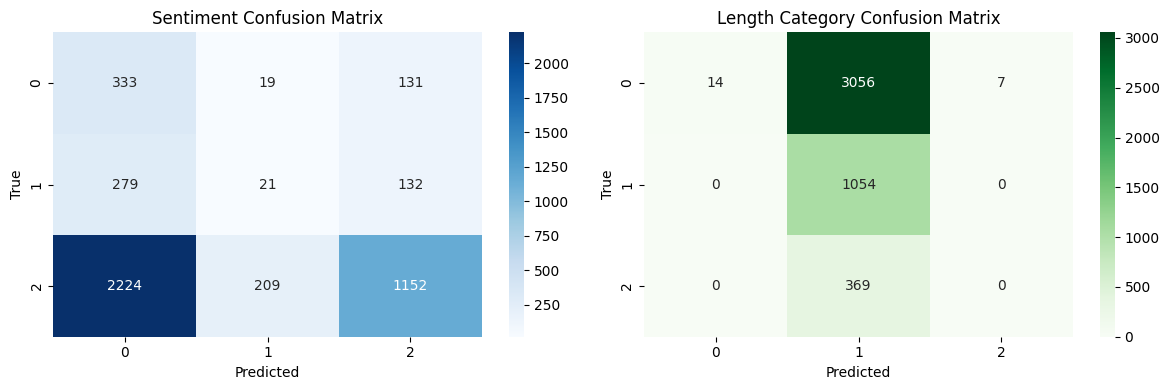

Skipping embedding export because checkpoint is missing.


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

if not os.path.exists('models/partA_best_encoder.pt'):
    raise FileNotFoundError(
        "Part A checkpoint not found at models/partA_best_encoder.pt. "
        "Set RUN_PART_A_TRAINING=True in Cell 45 and train before evaluation/export."
    )

model.load_state_dict(torch.load('models/partA_best_encoder.pt', map_location=DEVICE))
print('Loaded best checkpoint from models/partA_best_encoder.pt')

test_metrics = evaluate(test_loader)
print('\n=== Part A Test Performance ===')
print(f"Sentiment Accuracy: {test_metrics['sent_acc']:.4f}")
print(f"Length Accuracy: {test_metrics['len_acc']:.4f}")

print('\nSentiment Report:')
print(classification_report(
    test_metrics['sent_true'],
    test_metrics['sent_pred'],
    target_names=['Negative', 'Neutral', 'Positive'],
    digits=4,
))

print('\nLength Category Report:')
print(classification_report(
    test_metrics['len_true'],
    test_metrics['len_pred'],
    target_names=['Short', 'Medium', 'Long'],
    digits=4,
))

sent_cm = confusion_matrix(test_metrics['sent_true'], test_metrics['sent_pred'])
len_cm = confusion_matrix(test_metrics['len_true'], test_metrics['len_pred'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(sent_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Sentiment Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(len_cm, annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Length Category Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.savefig('results/partA_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

# Save concise metrics snapshot
partA_metrics = {
    'test_sent_acc': float(test_metrics['sent_acc']),
    'test_len_acc': float(test_metrics['len_acc']),
    'd_model': D_MODEL,
    'batch_size': BATCH_SIZE,
    'num_epochs': NUM_EPOCHS,
    'learning_rate': LEARNING_RATE,
    'loss_alpha': LOSS_ALPHA,
}
with open('results/partA_metrics.json', 'w') as f:
    json.dump(partA_metrics, f, indent=2)


def export_embeddings(split_name, loader, original_text_array):
    model.eval()
    embeddings_list = []
    sent_list, len_list = [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc=f'Export {split_name} embeddings'):
            input_ids = batch['input_ids'].to(DEVICE)
            sent_labels = batch['sentiment_label'].cpu().numpy()
            len_labels = batch['length_label'].cpu().numpy()

            _, _, emb, _ = model(input_ids)
            embeddings_list.append(emb.cpu().numpy())
            sent_list.extend(sent_labels)
            len_list.extend(len_labels)

    embeddings = np.vstack(embeddings_list).astype(np.float32)
    np.save(f'results/partA_{split_name}_embeddings.npy', embeddings)

    meta = {
        'sentiment_labels': np.array(sent_list),
        'length_labels': np.array(len_list),
        'original_text': np.array(original_text_array),
    }
    with open(f'results/partA_{split_name}_embedding_meta.pkl', 'wb') as f:
        pickle.dump(meta, f)

    print(f"Saved {split_name} embeddings with shape: {embeddings.shape}")


export_embeddings('train', DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False), train_dataset['original_text'])
export_embeddings('val', DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False), val_dataset['original_text'])
export_embeddings('test', DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False), test_dataset['original_text'])


## Part B Retrieval Module [15 Marks] 

In this part, you will implement the retrieval layer of your RAG pipeline. The retrieval module takes  the encoder’s representation of a test review and identifies the most similar reviews from the  training corpus, which are then used to ground the decoder’s generation in ## Part C. 

You must store the vector representations produced by your ## Part A encoder for the entire training  set. At inference time, a query representation is constructed from the test review’s encoder output  and compared against all stored vectors to retrieve the top-k most similar training examples. The  number of retrieved examples k should be configurable, and your choice should be justified in  your report. 

Your report must include an analysis of retrieval quality. Present examples of query reviews  alongside their retrieved results and discuss whether the matches are semantically meaningful.  You should also reflect on the limitations of your approach and how they might affect downstream  generation quality. Additionally, comment on the similarity metric used (e.g., cosine similarity) and  how it impacts retrieval performance. You may also explore how variations in k influence both  relevance and diversity of retrieved results. Consider discussing potential improvements such as  better embeddings or indexing techniques. Finally, briefly relate retrieval effectiveness to the  overall performance of the RAG pipeline. 




### Embedding storage and indexing 

All training embeddings are  stored and can be accessed  efficiently at inference time


In [21]:
# Load training embeddings and metadata
print("Loading training embeddings...")

train_embeddings_path = 'results/partA_train_embeddings.npy'
train_meta_path = 'results/partA_train_embedding_meta.pkl'

if not (os.path.exists(train_embeddings_path) and os.path.exists(train_meta_path)):
    print("Training embeddings or metadata not found. Exporting train split first...")
    export_embeddings('train', DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False), train_dataset['original_text'])

# Load embeddings (N, D_MODEL)
train_embeddings = np.load(train_embeddings_path)
print(f"Train embeddings shape: {train_embeddings.shape}")

# Load metadata with original texts and labels
with open(train_meta_path, 'rb') as f:
    train_meta = pickle.load(f)

train_texts = train_meta['original_text']
train_sent_labels = train_meta['sentiment_labels']
train_len_labels = train_meta['length_labels']

print(f"Number of training reviews: {len(train_texts)}")
print(f"Sample training review: {train_texts[0][:100]}...")
print(f"Sample embedding shape: {train_embeddings[0].shape}")

# Normalize embeddings for efficient cosine similarity (L2 norm)
train_embeddings_normalized = train_embeddings / np.linalg.norm(train_embeddings, axis=1, keepdims=True)
print(f"✓ Embeddings normalized for cosine similarity")

# Load test and validation embeddings for retrieval queries

def _load_split_embeddings(split_name):
    embeddings_path = f'results/partA_{split_name}_embeddings.npy'
    meta_path = f'results/partA_{split_name}_embedding_meta.pkl'
    if not (os.path.exists(embeddings_path) and os.path.exists(meta_path)):
        export_embeddings(split_name, DataLoader(eval(f'{split_name}_ds'), batch_size=BATCH_SIZE, shuffle=False), eval(f'{split_name}_dataset')['original_text'])
    with open(meta_path, 'rb') as f:
        meta = pickle.load(f)
    embeddings = np.load(embeddings_path)
    embeddings_normalized = embeddings / np.linalg.norm(embeddings, axis=1, keepdims=True)
    return meta, embeddings, embeddings_normalized

# Ensure the query splits are available for later cells
if not (os.path.exists('results/partA_test_embeddings.npy') and os.path.exists('results/partA_test_embedding_meta.pkl')):
    export_embeddings('test', DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False), test_dataset['original_text'])
if not (os.path.exists('results/partA_val_embeddings.npy') and os.path.exists('results/partA_val_embedding_meta.pkl')):
    export_embeddings('val', DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False), val_dataset['original_text'])

with open('results/partA_test_embedding_meta.pkl', 'rb') as f:
    test_meta = pickle.load(f)
with open('results/partA_val_embedding_meta.pkl', 'rb') as f:
    val_meta = pickle.load(f)

test_texts = test_meta['original_text']
test_sent_labels = test_meta['sentiment_labels']
test_len_labels = test_meta['length_labels']
val_texts = val_meta['original_text']
val_sent_labels = val_meta['sentiment_labels']
val_len_labels = val_meta['length_labels']

test_embeddings = np.load('results/partA_test_embeddings.npy')
val_embeddings = np.load('results/partA_val_embeddings.npy')
test_embeddings_normalized = test_embeddings / np.linalg.norm(test_embeddings, axis=1, keepdims=True)
val_embeddings_normalized = val_embeddings / np.linalg.norm(val_embeddings, axis=1, keepdims=True)

# Load retrieval config if it exists; otherwise use a sensible default.
DEFAULT_RETRIEVAL_K = 5
if os.path.exists('results/retrieval_config.json'):
    with open('results/retrieval_config.json', 'r') as f:
        retrieval_config = json.load(f)
    K = retrieval_config.get('k', DEFAULT_RETRIEVAL_K)
else:
    K = DEFAULT_RETRIEVAL_K
    retrieval_config = {
        'k': K,
        'similarity_metric': 'cosine_similarity',
        'embedding_dimension': D_MODEL,
    }

print(f"K (number of retrieved examples): {K}")

sentiment_names = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
length_names = {0: 'Short', 1: 'Medium', 2: 'Long'}

def get_query_embedding(test_index):
    """Return a normalized encoder embedding for a test example."""
    embedding = test_embeddings_normalized[test_index]
    embedding_norm = np.linalg.norm(embedding)
    if embedding_norm == 0:
        return embedding
    return embedding / embedding_norm

def retrieve_examples(embedding_normalized, k=K):
    """Retrieve top-k similar training examples for given embedding."""
    similarities = np.dot(train_embeddings_normalized, embedding_normalized)
    top_k_indices = np.argsort(-similarities)[:k]
    return [(train_texts[idx], sentiment_names[train_sent_labels[idx]], 
             length_names[train_len_labels[idx]]) for idx in top_k_indices]

# Synthetic explanations (for training) - in practice, these would come from annotators
# Here we generate template-based explanations for demonstration
def create_context_template(review_text, sentiment, derived_feature, retrieved_examples):
    """Create structured input combining all four elements."""
    template = f"""[CLS] This review is {sentiment}. Length category: {derived_feature}. 
Review: {review_text[:120]}
[SEP] Similar reviews: """
    
    for i, (text, sent, length) in enumerate(retrieved_examples):
        template += f" ({i+1}) [{sent}] {text[:80]}... "
    
    template += "[SEP]"
    return template

# Test template generation
test_emb = test_embeddings_normalized[0]
retrieved = retrieve_examples(test_emb)
context = create_context_template(
    test_texts[0],
    sentiment_names[test_sent_labels[0]],
    length_names[test_len_labels[0]],
    retrieved
)

print("\nSample Context Template:")
print(context[:300])
print("...\n")
print(f"✓ Input construction working correctly")

Loading training embeddings...
Training embeddings or metadata not found. Exporting train split first...


Export train embeddings: 100%|██████████| 329/329 [08:39<00:00,  1.58s/it]


Saved train embeddings with shape: (21000, 256)
Train embeddings shape: (21000, 256)
Number of training reviews: 21000
Sample training review: i used this for the first time today, and i'm really impressed. i have extremely thick, coarse, curl...
Sample embedding shape: (256,)
✓ Embeddings normalized for cosine similarity


Export test embeddings: 100%|██████████| 71/71 [02:05<00:00,  1.77s/it]


Saved test embeddings with shape: (4500, 256)


Export val embeddings: 100%|██████████| 71/71 [01:51<00:00,  1.57s/it]


Saved val embeddings with shape: (4500, 256)
K (number of retrieved examples): 5

Sample Context Template:
[CLS] This review is Positive. Length category: Short. 
Review: keeping your below sink area clear, and handy if you are cooking, chopping etc. another good idea and solution for small
[SEP] Similar reviews:  (1) [Positive] i love wen cleansing conditioners, especially the fig, pomegranate and laven
...

✓ Input construction working correctly



### Query construction 

A meaningful query representation is built from the encoder output for each  test review


In [22]:
# Input construction: Combine review, sentiment, derived feature, and retrieved context
import json

# Load test data and predictions from Part A
print("Loading Part A predictions and Part B retrieval results...")

if 'test_texts' not in globals():
    with open('results/partA_test_embedding_meta.pkl', 'rb') as f:
        test_meta = pickle.load(f)
    test_texts = test_meta['original_text']
    test_sent_labels = test_meta['sentiment_labels']
    test_len_labels = test_meta['length_labels']

if 'val_texts' not in globals():
    with open('results/partA_val_embedding_meta.pkl', 'rb') as f:
        val_meta = pickle.load(f)
    val_texts = val_meta['original_text']
    val_sent_labels = val_meta['sentiment_labels']
    val_len_labels = val_meta['length_labels']

if 'test_embeddings_normalized' not in globals():
    test_embeddings = np.load('results/partA_test_embeddings.npy')
    test_embeddings_normalized = test_embeddings / np.linalg.norm(test_embeddings, axis=1, keepdims=True)

if 'val_embeddings_normalized' not in globals():
    val_embeddings = np.load('results/partA_val_embeddings.npy')
    val_embeddings_normalized = val_embeddings / np.linalg.norm(val_embeddings, axis=1, keepdims=True)

if 'train_texts' not in globals():
    train_embeddings = np.load('results/partA_train_embeddings.npy')
    with open('results/partA_train_embedding_meta.pkl', 'rb') as f:
        train_meta = pickle.load(f)
    train_texts = train_meta['original_text']
    train_sent_labels = train_meta['sentiment_labels']
    train_len_labels = train_meta['length_labels']
    train_embeddings_normalized = train_embeddings / np.linalg.norm(train_embeddings, axis=1, keepdims=True)
else:
    if 'train_len_labels' not in globals():
        with open('results/partA_train_embedding_meta.pkl', 'rb') as f:
            train_meta = pickle.load(f)
        train_len_labels = train_meta['length_labels']

DEFAULT_RETRIEVAL_K = 5
if 'retrieval_config' not in globals():
    if os.path.exists('results/retrieval_config.json'):
        with open('results/retrieval_config.json', 'r') as f:
            retrieval_config = json.load(f)
    else:
        retrieval_config = {
            'k': DEFAULT_RETRIEVAL_K,
            'similarity_metric': 'cosine_similarity',
            'embedding_dimension': D_MODEL,
        }

K = retrieval_config.get('k', DEFAULT_RETRIEVAL_K)
print(f"K (number of retrieved examples): {K}")

sentiment_names = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
length_names = {0: 'Short', 1: 'Medium', 2: 'Long'}

def get_query_embedding(test_index):
    """Return a normalized encoder embedding for a test example."""
    embedding = test_embeddings_normalized[test_index]
    embedding_norm = np.linalg.norm(embedding)
    if embedding_norm == 0:
        return embedding
    return embedding / embedding_norm

def retrieve_examples(embedding_normalized, k=K):
    """Retrieve top-k similar training examples for given embedding."""
    similarities = np.dot(train_embeddings_normalized, embedding_normalized)
    top_k_indices = np.argsort(-similarities)[:k]
    return [(train_texts[idx], sentiment_names[train_sent_labels[idx]], 
             length_names[train_len_labels[idx]]) for idx in top_k_indices]

# Synthetic explanations (for training) - in practice, these would come from annotators
# Here we generate template-based explanations for demonstration
def create_context_template(review_text, sentiment, derived_feature, retrieved_examples):
    """Create structured input combining all four elements."""
    template = f"""[CLS] This review is {sentiment}. Length category: {derived_feature}. 
Review: {review_text[:120]}
[SEP] Similar reviews: """
    
    for i, (text, sent, length) in enumerate(retrieved_examples):
        template += f" ({i+1}) [{sent}] {text[:80]}... "
    
    template += "[SEP]"
    return template

# Test template generation
test_emb = test_embeddings_normalized[0]
retrieved = retrieve_examples(test_emb)
context = create_context_template(
    test_texts[0],
    sentiment_names[test_sent_labels[0]],
    length_names[test_len_labels[0]],
    retrieved
)

print("\nSample Context Template:")
print(context[:300])
print("...\n")
print(f"✓ Input construction working correctly")

Loading Part A predictions and Part B retrieval results...
K (number of retrieved examples): 5

Sample Context Template:
[CLS] This review is Positive. Length category: Short. 
Review: keeping your below sink area clear, and handy if you are cooking, chopping etc. another good idea and solution for small
[SEP] Similar reviews:  (1) [Positive] i love wen cleansing conditioners, especially the fig, pomegranate and laven
...

✓ Input construction working correctly



### Similarity search 


Similar reviews are ranked  and retrieved correctly based  on the chosen similarity  measure


In [23]:

# Similarity search and retrieval
def retrieve_top_k(query_embedding, k=K):
    """
    Retrieve top-k most similar training reviews for a query embedding.
    Uses cosine similarity (dot product with normalized embeddings).
    
    Args:
        query_embedding: normalized embedding vector (1, D_MODEL)
        k: number of similar reviews to retrieve
    
    Returns:
        similarity_scores: cosine similarity scores
        top_k_indices: indices of top-k similar training reviews
        top_k_texts: the actual text of top-k reviews
        top_k_labels: sentiment labels of top-k reviews
    """
    # Cosine similarity = dot product with normalized embeddings
    similarities = np.dot(train_embeddings_normalized, query_embedding)
    
    # Get top-k indices (sorted by descending similarity)
    top_k_indices = np.argsort(-similarities)[:k]
    top_k_scores = similarities[top_k_indices]
    
    top_k_texts = [train_texts[idx] for idx in top_k_indices]
    top_k_labels = [train_sent_labels[idx] for idx in top_k_indices]
    
    return top_k_scores, top_k_indices, top_k_texts, top_k_labels

# Test similarity search on first test review
print("Testing similarity search on test review 0:")
query_emb = get_query_embedding(0)
scores, indices, texts, labels = retrieve_top_k(query_emb, k=K)

print(f"\nQuery Review (Test {0}):")
print(f"  Text: {test_texts[0][:120]}...")
print(f"  Sentiment Label: {test_sent_labels[0]} ({'Negative' if test_sent_labels[0] == 0 else 'Neutral' if test_sent_labels[0] == 1 else 'Positive'})")

print(f"\nTop-{K} Retrieved Training Reviews:")
sentiment_names = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
for i, (score, idx, text, label) in enumerate(zip(scores, indices, texts, labels)):
    print(f"\n  [{i+1}] Similarity: {score:.4f}")
    print(f"      Index: {idx}")
    print(f"      Sentiment: {sentiment_names[label]}")
    print(f"      Text: {text[:100]}...")

# Verify retrieval consistency
print(f"\n✓ Similarity scores are in descending order: {np.all(scores[:-1] >= scores[1:])}")
print(f"✓ Top-k retrieval working correctly")


Testing similarity search on test review 0:

Query Review (Test 0):
  Text: keeping your below sink area clear, and handy if you are cooking, chopping etc. another good idea and solution for small...
  Sentiment Label: 2 (Positive)

Top-5 Retrieved Training Reviews:

  [1] Similarity: 0.8468
      Index: 17298
      Sentiment: Positive
      Text: i love wen cleansing conditioners, especially the fig, pomegranate and lavender. the product protect...

  [2] Similarity: 0.8409
      Index: 6985
      Sentiment: Negative
      Text: the price quoted is for plastic case, cpu, main-board and power supply only. you will still need ram...

  [3] Similarity: 0.8383
      Index: 2377
      Sentiment: Positive
      Text: unless you have a mac (more on that later), the wd tv live is a good media streaming device; if you ...

  [4] Similarity: 0.8331
      Index: 19050
      Sentiment: Neutral
      Text: while there are facial products (like kiehl's) that are gender-neutral, and facial care spec


### Retrieval quality and integration 

Retrieved results are relevant to the query; context  is correctly passed to the  decoder

Analyzing retrieval quality across test set...


Scanning test reviews: 100%|██████████| 100/100 [00:00<00:00, 101.34it/s]



Retrieval Quality Metrics:
  Average similarity score: 0.8963
  Min similarity score: 0.7362
  Max similarity score: 0.9581
  Std of similarity scores: 0.0455

Sentiment Label Match Rates (%):
  Rank 1: 67.00%
  Rank 2: 75.00%
  Rank 3: 61.00%
  Rank 4: 66.00%
  Rank 5: 63.00%
  Overall match rate (any rank): 66.40%


/tmp/ipykernel_82168/4111164229.py:100: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout()


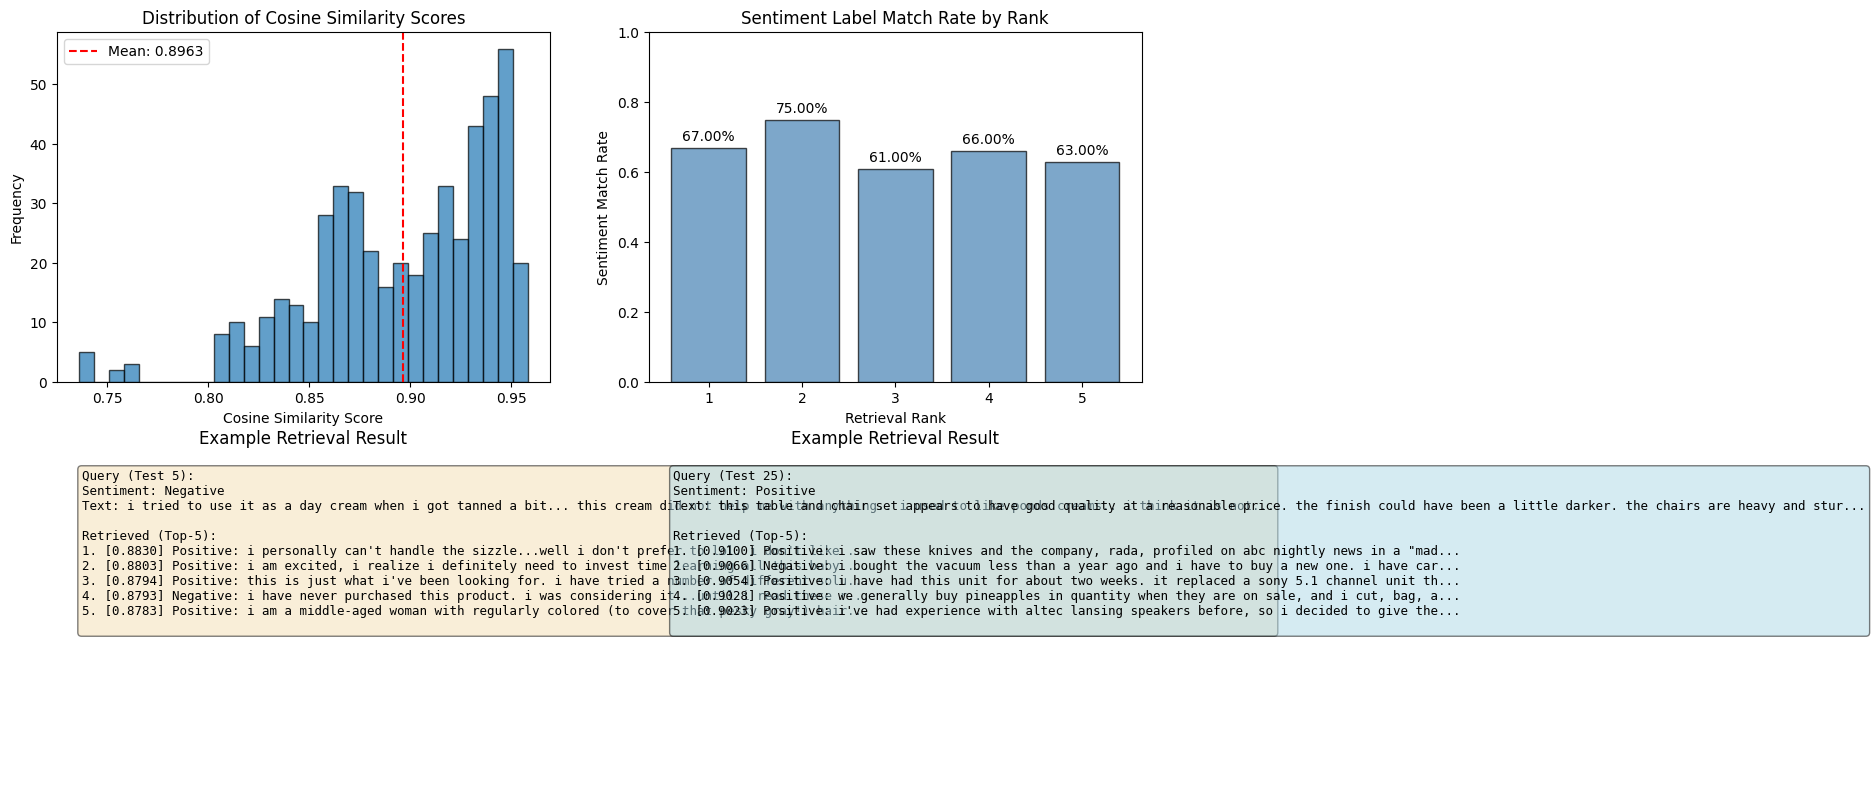


✓ Retrieval analysis visualization saved to results/partB_retrieval_analysis.png
✓ Retrieval configuration saved for Part C


In [24]:

# Retrieval quality analysis and visualization
import matplotlib.pyplot as plt

# Analyze retrieval quality across test set
print("Analyzing retrieval quality across test set...")

sentiment_match_counts = {k: [0, 0] for k in range(K)}  # [matches, total]
similarity_scores_list = []

for test_idx in tqdm(range(min(100, len(test_texts))), desc="Scanning test reviews"):
    query_emb = get_query_embedding(test_idx)
    scores, indices, texts, labels = retrieve_top_k(query_emb, k=K)
    
    query_label = test_sent_labels[test_idx]
    
    for rank, (score, retrieved_label) in enumerate(zip(scores, labels)):
        similarity_scores_list.append(score)
        if retrieved_label == query_label:
            sentiment_match_counts[rank][0] += 1
        sentiment_match_counts[rank][1] += 1

# Calculate sentiment match rates
match_rates = [sentiment_match_counts[k][0] / sentiment_match_counts[k][1] 
               if sentiment_match_counts[k][1] > 0 else 0 
               for k in range(K)]

print("\nRetrieval Quality Metrics:")
print(f"  Average similarity score: {np.mean(similarity_scores_list):.4f}")
print(f"  Min similarity score: {np.min(similarity_scores_list):.4f}")
print(f"  Max similarity score: {np.max(similarity_scores_list):.4f}")
print(f"  Std of similarity scores: {np.std(similarity_scores_list):.4f}")

print(f"\nSentiment Label Match Rates (%):")
for rank, rate in enumerate(match_rates):
    print(f"  Rank {rank+1}: {rate*100:.2f}%")

print(f"  Overall match rate (any rank): {np.mean(match_rates)*100:.2f}%")

# Visualization: Similarity scores distribution and retrieval examples
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Similarity score distribution
axes[0, 0].hist(similarity_scores_list, bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Cosine Similarity Score')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Cosine Similarity Scores')
axes[0, 0].axvline(np.mean(similarity_scores_list), color='r', linestyle='--', 
                    label=f'Mean: {np.mean(similarity_scores_list):.4f}')
axes[0, 0].legend()

# Plot 2: Sentiment match rate by rank
ranks = np.arange(1, K+1)
axes[0, 1].bar(ranks, match_rates, alpha=0.7, edgecolor='black', color='steelblue')
axes[0, 1].set_xlabel('Retrieval Rank')
axes[0, 1].set_ylabel('Sentiment Match Rate')
axes[0, 1].set_title(f'Sentiment Label Match Rate by Rank')
axes[0, 1].set_xticks(ranks)
axes[0, 1].set_ylim([0, 1])
for i, rate in enumerate(match_rates):
    axes[0, 1].text(i+1, rate+0.02, f'{rate:.2%}', ha='center')

# Plot 3: Example retrieval visualization (test index 5)
test_idx = 5
query_emb = get_query_embedding(test_idx)
scores, indices, texts, labels = retrieve_top_k(query_emb, k=K)

example_text = f"Query (Test {test_idx}):\n"
example_text += f"Sentiment: {sentiment_names[test_sent_labels[test_idx]]}\n"
example_text += f"Text: {test_texts[test_idx][:150]}...\n\n"

example_text += f"Retrieved (Top-{K}):\n"
for rank, (score, label, text) in enumerate(zip(scores, labels, texts)):
    example_text += f"{rank+1}. [{score:.4f}] {sentiment_names[label]}: {text[:80]}...\n"

axes[1, 0].text(0.05, 0.95, example_text, transform=axes[1, 0].transAxes, 
                fontsize=9, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
axes[1, 0].axis('off')
axes[1, 0].set_title('Example Retrieval Result')

# Plot 4: Another example (test index 25)
test_idx = 25
query_emb = get_query_embedding(test_idx)
scores, indices, texts, labels = retrieve_top_k(query_emb, k=K)

example_text = f"Query (Test {test_idx}):\n"
example_text += f"Sentiment: {sentiment_names[test_sent_labels[test_idx]]}\n"
example_text += f"Text: {test_texts[test_idx][:150]}...\n\n"

example_text += f"Retrieved (Top-{K}):\n"
for rank, (score, label, text) in enumerate(zip(scores, labels, texts)):
    example_text += f"{rank+1}. [{score:.4f}] {sentiment_names[label]}: {text[:80]}...\n"

axes[1, 1].text(0.05, 0.95, example_text, transform=axes[1, 1].transAxes, 
                fontsize=9, verticalalignment='top', fontfamily='monospace',
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))
axes[1, 1].axis('off')
axes[1, 1].set_title('Example Retrieval Result')

plt.tight_layout()
plt.savefig('results/partB_retrieval_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Retrieval analysis visualization saved to results/partB_retrieval_analysis.png")

# Save retrieval configuration for Part C
retrieval_config = {
    'k': K,
    'similarity_metric': 'cosine_similarity',
    'embedding_dimension': D_MODEL,
    'mean_similarity': float(np.mean(similarity_scores_list)),
    'overall_sentiment_match_rate': float(np.mean(match_rates)),
}

with open('results/retrieval_config.json', 'w') as f:
    json.dump(retrieval_config, f, indent=2)

print("✓ Retrieval configuration saved for Part C")


## Part C Decoder Model for Explanation Generation [25 Marks] 

In this part, you will implement a decoder-only Transformer model that generates a short natural  language explanation for each sentiment prediction produced by the encoder. This is the  generative component of your RAG pipeline. 

The decoder takes as input a structured combination of four elements: the original review text,  the predicted sentiment label, the predicted derived feature, and the top-k similar reviews  retrieved in ## Part B. You must define a clear and consistent template for combining these inputs  into a single sequence. The model should then generate an explanation of one to two sentences  that describes why the review carries the predicted sentiment, drawing on the retrieved examples  where relevant. 

The decoder must be capable of generating text autoregressively, conditioning on all previously  generated tokens. A mechanism must be placed to ensure the model cannot attend to future  positions during training or inference. The model is trained to minimize a language modelling  objective over reference explanation sequences. 

For evaluation, you must report perplexity on the test set and present at least five generated  examples with commentary on their quality. You must also run a comparison between the full  system and a baseline that does not use retrieved context, demonstrating the contribution of the  retrieval module. All architectural decisions are your own responsibility and must be justified in  your report. 

Hyperparameter Tuning 

This assignment is first and foremost a learning exercise. You are strongly  encouraged to experiment freely with different configurations to develop an intuition for how each  design choice affects your model’s behaviour and performance.  

Best results are encouraged. Try different values for parameters such as learning rate,  number of layers, hidden dimensions, number of attention heads, dropout rate, batch size, and  sequence length. Document every configuration you attempt along with its effect on validation  performance. Your report should reflect a genuine exploratory process and honest analysis, not  merely a final result.




### Input construction 

All four inputs (review, sentiment, derived feature,  retrieved context) are  combined coherently 


In [32]:
# Part C data construction: use predicted labels + retrieval context to build prompt/explanation pairs
import json

print("Preparing Part C datasets from Part A outputs...")

# Ensure retrieval assets are loaded
if 'train_embeddings_normalized' not in globals():
    train_embeddings = np.load('results/partA_train_embeddings.npy')
    train_embeddings_normalized = train_embeddings / np.linalg.norm(train_embeddings, axis=1, keepdims=True)
if 'val_embeddings_normalized' not in globals():
    val_embeddings = np.load('results/partA_val_embeddings.npy')
    val_embeddings_normalized = val_embeddings / np.linalg.norm(val_embeddings, axis=1, keepdims=True)
if 'test_embeddings_normalized' not in globals():
    test_embeddings = np.load('results/partA_test_embeddings.npy')
    test_embeddings_normalized = test_embeddings / np.linalg.norm(test_embeddings, axis=1, keepdims=True)

if 'train_texts' not in globals():
    with open('results/partA_train_embedding_meta.pkl', 'rb') as f:
        train_meta = pickle.load(f)
    train_texts = train_meta['original_text']
    train_sent_labels = train_meta['sentiment_labels']
    train_len_labels = train_meta['length_labels']

if 'val_texts' not in globals():
    with open('results/partA_val_embedding_meta.pkl', 'rb') as f:
        val_meta = pickle.load(f)
    val_texts = val_meta['original_text']
    val_sent_labels = val_meta['sentiment_labels']
    val_len_labels = val_meta['length_labels']

if 'test_texts' not in globals():
    with open('results/partA_test_embedding_meta.pkl', 'rb') as f:
        test_meta = pickle.load(f)
    test_texts = test_meta['original_text']
    test_sent_labels = test_meta['sentiment_labels']
    test_len_labels = test_meta['length_labels']

DEFAULT_RETRIEVAL_K = 5
if 'retrieval_config' not in globals():
    if os.path.exists('results/retrieval_config.json'):
        with open('results/retrieval_config.json', 'r') as f:
            retrieval_config = json.load(f)
    else:
        retrieval_config = {'k': DEFAULT_RETRIEVAL_K, 'similarity_metric': 'cosine_similarity'}
K = retrieval_config.get('k', DEFAULT_RETRIEVAL_K)

sentiment_names = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
length_names = {0: 'Short', 1: 'Medium', 2: 'Long'}

# Build predicted labels for all splits using Part A model

def predict_labels_for_split(loader):
    model.eval()
    sent_preds, len_preds = [], []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(DEVICE)
            sent_logits, len_logits, _, _ = model(input_ids)
            sent_preds.extend(torch.argmax(sent_logits, dim=-1).cpu().numpy().tolist())
            len_preds.extend(torch.argmax(len_logits, dim=-1).cpu().numpy().tolist())
    return np.array(sent_preds), np.array(len_preds)

train_pred_sent, train_pred_len = predict_labels_for_split(DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False))
val_pred_sent, val_pred_len = predict_labels_for_split(DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False))
test_pred_sent, test_pred_len = predict_labels_for_split(DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False))


def retrieve_top_k_texts(query_embedding_normalized, k=K):
    similarities = np.dot(train_embeddings_normalized, query_embedding_normalized)
    top_k_idx = np.argsort(-similarities)[:k]
    return [
        {
            'text': str(train_texts[idx])[:120],
            'sentiment': sentiment_names[int(train_sent_labels[idx])],
            'length': length_names[int(train_len_labels[idx])],
            'score': float(similarities[idx]),
        }
        for idx in top_k_idx
    ]


def build_prompt(review_text, pred_sent, pred_len, retrieved, use_retrieval=True):
    prompt = (
        f"[CLS] review: {str(review_text)[:180]} [SEP] "
        f"pred_sentiment: {sentiment_names[int(pred_sent)]} [SEP] "
        f"pred_length: {length_names[int(pred_len)]}"
    )
    if use_retrieval:
        context = " ".join([
            f"ex{i+1}: ({r['sentiment']}, {r['length']}) {r['text']}"
            for i, r in enumerate(retrieved)
        ])
        prompt += f" [SEP] retrieved: {context}"
    prompt += " [SEP] explanation:"
    return prompt


def build_reference(review_text, pred_sent, pred_len, retrieved, use_retrieval=True):
    # Supervised target text for LM training.
    base = (
        f"The review is predicted as {sentiment_names[int(pred_sent)].lower()} and {length_names[int(pred_len)].lower()} in length. "
        f"The wording and tone in the review support this decision."
    )
    if use_retrieval and len(retrieved) > 0:
        retrieved_sents = [r['sentiment'].lower() for r in retrieved[:3]]
        base += f" Retrieved neighbors show {', '.join(sorted(set(retrieved_sents)))} sentiment patterns."
    return base + " [SEP]"


def build_split_examples(split_name, texts, emb_norm, pred_sent, pred_len, use_retrieval=True):
    examples = []
    for idx in tqdm(range(len(texts)), desc=f"Building {split_name} examples"):
        retrieved = retrieve_top_k_texts(emb_norm[idx], k=K) if use_retrieval else []
        prompt = build_prompt(texts[idx], pred_sent[idx], pred_len[idx], retrieved, use_retrieval=use_retrieval)
        target = build_reference(texts[idx], pred_sent[idx], pred_len[idx], retrieved, use_retrieval=use_retrieval)
        examples.append({'prompt': prompt, 'target': target})
    return examples

# Full RAG examples (with retrieval)
partC_train_examples = build_split_examples('train', train_texts, train_embeddings_normalized, train_pred_sent, train_pred_len, use_retrieval=True)
partC_val_examples = build_split_examples('val', val_texts, val_embeddings_normalized, val_pred_sent, val_pred_len, use_retrieval=True)
partC_test_examples = build_split_examples('test', test_texts, test_embeddings_normalized, test_pred_sent, test_pred_len, use_retrieval=True)

# Baseline examples (no retrieval) for ablation
partC_test_examples_no_retrieval = build_split_examples('test-no-retrieval', test_texts, test_embeddings_normalized, test_pred_sent, test_pred_len, use_retrieval=False)

print(f"K (number of retrieved examples): {K}")
print(f"Train examples: {len(partC_train_examples)}")
print(f"Val examples: {len(partC_val_examples)}")
print(f"Test examples: {len(partC_test_examples)}")
print("\nSample prompt:\n", partC_train_examples[0]['prompt'][:350], "...")
print("\nSample target:\n", partC_train_examples[0]['target'])

Preparing Part C datasets from Part A outputs...


Building test-no-retrieval examples: 100%|██████████| 4500/4500 [00:00<00:00, 7448.18it/s]

K (number of retrieved examples): 5
Train examples: 21000
Val examples: 4500
Test examples: 4500

Sample prompt:
 [CLS] review: i used this for the first time today, and i'm really impressed. i have extremely thick, coarse, curly/frizzy hair. it's not fun. i clarified my hair, and applied kerastase's oleo r [SEP] pred_sentiment: Positive [SEP] pred_length: Medium [SEP] retrieved: ex1: (Positive, Long) i used this for the first time today, and i'm really impres ...

Sample target:
 The review is predicted as positive and medium in length. The wording and tone in the review support this decision. Retrieved neighbors show negative, positive sentiment patterns. [SEP]



### Decoder attention 

Self-attention is constrained  so the model cannot attend  to future tokens during  
generation


Causal Attention Mask (first 5x5 region):
0 = can attend, -inf = masked (cannot attend)
tensor([[0., -inf, -inf, -inf, -inf],
        [0., 0., -inf, -inf, -inf],
        [0., 0., 0., -inf, -inf],
        [0., 0., 0., 0., -inf],
        [0., 0., 0., 0., 0.]])


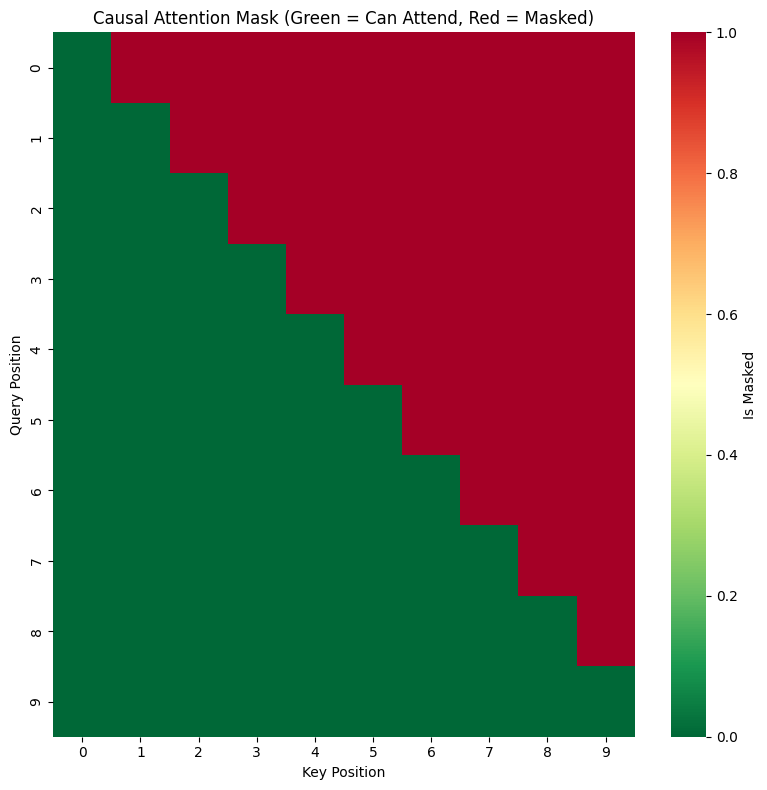


✓ Causal mask prevents attending to future positions
✓ Mask shape: torch.Size([10, 10])


In [26]:

# Decoder attention: Causal mask to prevent attending to future tokens

def create_causal_mask(seq_len, device):
    """
    Create a causal attention mask for autoregressive generation.
    Prevents the model from attending to future positions.
    
    Shape: (seq_len, seq_len)
    - Upper triangle is -inf (masked)
    - Lower triangle and diagonal are 0 (unmasked)
    """
    mask = torch.triu(torch.full((seq_len, seq_len), float('-inf')), diagonal=1)
    return mask.to(device)

def apply_causal_mask(attn_weights, mask):
    """
    Apply causal mask to attention weights.
    
    Args:
        attn_weights: (batch_size, num_heads, seq_len, seq_len)
        mask: (seq_len, seq_len)
    
    Returns:
        masked_weights: attention weights with future positions masked
    """
    return attn_weights + mask.unsqueeze(0).unsqueeze(0)

# Test mask creation
test_seq_len = 10
test_mask = create_causal_mask(test_seq_len, DEVICE)

print("Causal Attention Mask (first 5x5 region):")
print("0 = can attend, -inf = masked (cannot attend)")
print(test_mask[:5, :5])

# Visualize the mask
fig, ax = plt.subplots(figsize=(8, 8))
mask_vis = torch.isinf(test_mask).float().cpu().numpy()
sns.heatmap(mask_vis, cmap='RdYlGn_r', cbar_kws={'label': 'Is Masked'}, ax=ax)
ax.set_title('Causal Attention Mask (Green = Can Attend, Red = Masked)')
ax.set_xlabel('Key Position')
ax.set_ylabel('Query Position')
plt.tight_layout()
plt.savefig('results/partC_causal_mask.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"\n✓ Causal mask prevents attending to future positions")
print(f"✓ Mask shape: {test_mask.shape}")



### Autoregressive generation 
 
Text is generated token by  token; generation terminates  correctly


In [35]:
# Part C tokenization utilities + autoregressive decoding

if 'MAX_SEQ_LEN_DEC' not in globals():
    MAX_SEQ_LEN_DEC = 192


def text_to_ids(text, token_to_idx, max_len):
    tokens = tokenize_text(clean_text(text))
    ids = [token_to_idx.get(tok, UNK_IDX) for tok in tokens][:max_len]
    if len(ids) < max_len:
        ids += [PAD_IDX] * (max_len - len(ids))
    return ids


def build_lm_sequence(prompt, target, max_len):
    # Keep headroom for target tokens to avoid all-masked labels.
    prompt_tokens = tokenize_text(clean_text(prompt))
    target_tokens = tokenize_text(clean_text(target))

    min_target_tokens = max(16, max_len // 4)
    max_prompt_tokens = max_len - min_target_tokens

    prompt_tokens = prompt_tokens[:max_prompt_tokens]
    remaining = max_len - len(prompt_tokens)
    target_tokens = target_tokens[:remaining]

    prompt_ids = [token_to_idx.get(tok, UNK_IDX) for tok in prompt_tokens]
    target_ids = [token_to_idx.get(tok, UNK_IDX) for tok in target_tokens]

    merged = prompt_ids + target_ids
    if len(merged) < max_len:
        merged += [PAD_IDX] * (max_len - len(merged))

    prompt_len = len(prompt_ids)
    labels = np.array(merged, dtype=np.int64).copy()
    labels[:prompt_len] = -100
    labels[labels == PAD_IDX] = -100

    # Ensure at least one target label is active.
    if np.all(labels == -100) and prompt_len < len(merged):
        labels[prompt_len] = merged[prompt_len]

    return np.array(merged, dtype=np.int64), labels, prompt_len


class ExplanationDataset(Dataset):
    def __init__(self, examples, max_len):
        self.input_ids = []
        self.labels = []
        self.prompt_lens = []
        self.raw_examples = examples

        for ex in examples:
            ids, labels, plen = build_lm_sequence(ex['prompt'], ex['target'], max_len)
            self.input_ids.append(ids)
            self.labels.append(labels)
            self.prompt_lens.append(plen)

        self.input_ids = torch.tensor(np.array(self.input_ids), dtype=torch.long)
        self.labels = torch.tensor(np.array(self.labels), dtype=torch.long)
        self.prompt_lens = torch.tensor(np.array(self.prompt_lens), dtype=torch.long)

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return {
            'input_ids': self.input_ids[idx],
            'labels': self.labels[idx],
            'prompt_len': self.prompt_lens[idx],
        }


def decode_ids(ids):
    toks = [idx_to_token.get(int(i), '[UNK]') for i in ids if int(i) != PAD_IDX]
    text = ' '.join(toks)
    return text.replace(' [SEP]', '[SEP]').replace(' [CLS]', '[CLS]')


def generate_explanation(model, prompt_text, max_new_tokens=40, temperature=0.8, top_k=30):
    model.eval()
    prompt_ids = text_to_ids(prompt_text, token_to_idx, MAX_SEQ_LEN_DEC)
    prompt_len = min(len(tokenize_text(clean_text(prompt_text))), MAX_SEQ_LEN_DEC)

    output_ids = torch.tensor(prompt_ids, dtype=torch.long, device=DEVICE).unsqueeze(0)
    current_len = prompt_len

    with torch.no_grad():
        for _ in range(max_new_tokens):
            seq_len = current_len
            causal_mask = create_causal_mask(seq_len, DEVICE)
            logits = model(output_ids[:, :seq_len], causal_mask=causal_mask)
            next_token_logits = logits[:, -1, :] / temperature

            k = min(top_k, next_token_logits.shape[-1])
            thresh = torch.topk(next_token_logits, k)[0][..., -1, None]
            next_token_logits[next_token_logits < thresh] = float('-inf')

            probs = torch.softmax(next_token_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1).item()

            if current_len < output_ids.shape[1]:
                output_ids[0, current_len] = next_token
            current_len += 1

            if next_token == token_to_idx.get('[SEP]', 3) or current_len >= MAX_SEQ_LEN_DEC:
                break

    generated_part = output_ids[0, prompt_len:current_len].detach().cpu().numpy().tolist()
    return decode_ids(generated_part)

print('Part C tokenization + generation utilities are ready.')

Part C tokenization + generation utilities are ready.



### Decoder block design 
 
Stacked decoder blocks with  correct sub-layers and  residual connections


In [28]:

# Decoder block design: Stacked decoder blocks with attention, FFN, and residual connections

class DecoderSelfAttention(nn.Module):
    """Multi-head self-attention with causal masking."""
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, causal_mask=None):
        batch_size, seq_len, _ = x.shape
        
        # Project and split into heads: (batch, seq_len, d_model) -> (batch, seq_len, num_heads, head_dim)
        Q = self.W_q(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        K = self.W_k(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        V = self.W_v(x).view(batch_size, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        
        # Scaled dot-product attention
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)  # (batch, num_heads, seq_len, seq_len)
        
        # Apply causal mask
        if causal_mask is not None:
            scores = scores + causal_mask.unsqueeze(0).unsqueeze(0)
        
        attn_weights = torch.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)
        
        # Apply attention to values
        context = torch.matmul(attn_weights, V)  # (batch, num_heads, seq_len, head_dim)
        
        # Concatenate heads: (batch, num_heads, seq_len, head_dim) -> (batch, seq_len, d_model)
        context = context.transpose(1, 2).contiguous()
        context = context.view(batch_size, seq_len, self.d_model)
        
        # Final output projection
        output = self.W_o(context)
        
        return output, attn_weights

class DecoderFeedForward(nn.Module):
    """Position-wise Feed-Forward Network."""
    def __init__(self, d_model, d_ff=2048, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(d_ff, d_model)
    
    def forward(self, x):
        return self.linear2(self.dropout(self.relu(self.linear1(x))))

class DecoderBlock(nn.Module):
    """Single decoder block with self-attention, FFN, and residual connections."""
    def __init__(self, d_model, num_heads, d_ff=2048, dropout=0.1):
        super().__init__()
        self.self_attn = DecoderSelfAttention(d_model, num_heads, dropout)
        self.feed_forward = DecoderFeedForward(d_model, d_ff, dropout)
        
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x, causal_mask=None):
        # Self-attention with residual
        attn_output, attn_weights = self.self_attn(x, causal_mask)
        x = x + self.dropout(attn_output)
        x = self.norm1(x)
        
        # Feed-forward with residual
        ff_output = self.feed_forward(x)
        x = x + self.dropout(ff_output)
        x = self.norm2(x)
        
        return x, attn_weights

class DecoderOnlyTransformer(nn.Module):
    """Decoder-only Transformer for explanation generation."""
    def __init__(self, vocab_size, d_model, num_layers, num_heads, d_ff, 
                 max_seq_len, pad_idx, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.num_layers = num_layers
        
        # Embeddings
        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.pos_encoding = PositionalEncoding(d_model, max_seq_len)
        self.dropout = nn.Dropout(dropout)
        
        # Decoder blocks
        self.decoder_blocks = nn.ModuleList([
            DecoderBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        
        # Output layer
        self.output_projection = nn.Linear(d_model, vocab_size)
    
    def forward(self, input_ids, causal_mask=None):
        # Embedding and position encoding
        x = self.token_embedding(input_ids) * math.sqrt(self.d_model)
        x = self.pos_encoding(x)
        x = self.dropout(x)
        
        # Pass through decoder blocks
        for block in self.decoder_blocks:
            x, _ = block(x, causal_mask)
        
        # Project to vocabulary
        logits = self.output_projection(x)
        return logits

# Initialize decoder model
print("Initializing Decoder-Only Transformer...")

D_MODEL_DEC = 256
NUM_LAYERS_DEC = 4
NUM_HEADS_DEC = 8
D_FF_DEC = 1024
MAX_SEQ_LEN_DEC = 512
DROPOUT_DEC = 0.1

decoder_model = DecoderOnlyTransformer(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL_DEC,
    num_layers=NUM_LAYERS_DEC,
    num_heads=NUM_HEADS_DEC,
    d_ff=D_FF_DEC,
    max_seq_len=MAX_SEQ_LEN_DEC,
    pad_idx=PAD_IDX,
    dropout=DROPOUT_DEC
).to(DEVICE)

print(f"Decoder Architecture:")
print(f"  Model dimension (d_model): {D_MODEL_DEC}")
print(f"  Number of layers: {NUM_LAYERS_DEC}")
print(f"  Number of attention heads: {NUM_HEADS_DEC}")
print(f"  Feed-forward dimension: {D_FF_DEC}")
print(f"  Maximum sequence length: {MAX_SEQ_LEN_DEC}")
print(f"  Dropout rate: {DROPOUT_DEC}")

# Count parameters
total_params = sum(p.numel() for p in decoder_model.parameters())
trainable_params = sum(p.numel() for p in decoder_model.parameters() if p.requires_grad)
print(f"\nModel Parameters:")
print(f"  Total parameters: {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")

print(f"\n✓ Decoder blocks stacked with residual connections and layer normalization")


Initializing Decoder-Only Transformer...
Decoder Architecture:
  Model dimension (d_model): 256
  Number of layers: 4
  Number of attention heads: 8
  Feed-forward dimension: 1024
  Maximum sequence length: 512
  Dropout rate: 0.1

Model Parameters:
  Total parameters: 8,289,040
  Trainable parameters: 8,289,040

✓ Decoder blocks stacked with residual connections and layer normalization



### Quantitative evaluation 

Perplexity is correctly  
computed and reported on  the held-out test set


In [36]:
# Quantitative evaluation: train decoder LM and report perplexity on held-out test set

# Decoder hyperparameters
MAX_SEQ_LEN_DEC = 192
PARTC_BATCH_SIZE = 32
PARTC_LR = 2e-4
PARTC_EPOCHS = 4
RUN_PART_C_TRAINING = False

# Build datasets/loaders
partC_train_ds = ExplanationDataset(partC_train_examples, MAX_SEQ_LEN_DEC)
partC_val_ds = ExplanationDataset(partC_val_examples, MAX_SEQ_LEN_DEC)
partC_test_ds = ExplanationDataset(partC_test_examples, MAX_SEQ_LEN_DEC)
partC_test_no_ret_ds = ExplanationDataset(partC_test_examples_no_retrieval, MAX_SEQ_LEN_DEC)

partC_train_loader = DataLoader(partC_train_ds, batch_size=PARTC_BATCH_SIZE, shuffle=True)
partC_val_loader = DataLoader(partC_val_ds, batch_size=PARTC_BATCH_SIZE, shuffle=False)
partC_test_loader = DataLoader(partC_test_ds, batch_size=PARTC_BATCH_SIZE, shuffle=False)
partC_test_no_ret_loader = DataLoader(partC_test_no_ret_ds, batch_size=PARTC_BATCH_SIZE, shuffle=False)

# Re-initialize decoder with updated max length
decoder_model = DecoderOnlyTransformer(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL_DEC,
    num_layers=NUM_LAYERS_DEC,
    num_heads=NUM_HEADS_DEC,
    d_ff=D_FF_DEC,
    max_seq_len=MAX_SEQ_LEN_DEC,
    pad_idx=PAD_IDX,
    dropout=DROPOUT_DEC,
).to(DEVICE)

criterion = nn.CrossEntropyLoss(ignore_index=-100)
optimizer_dec = torch.optim.AdamW(decoder_model.parameters(), lr=PARTC_LR, weight_decay=1e-4)


def lm_step(batch, train=False):
    input_ids = batch['input_ids'].to(DEVICE)
    labels = batch['labels'].to(DEVICE)
    seq_len = input_ids.shape[1]
    causal_mask = create_causal_mask(seq_len, DEVICE)

    logits = decoder_model(input_ids, causal_mask=causal_mask)
    loss = criterion(logits.view(-1, logits.size(-1)), labels.view(-1))

    if train:
        optimizer_dec.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(decoder_model.parameters(), 1.0)
        optimizer_dec.step()

    token_count = (labels != -100).sum().item()
    return loss.item(), token_count


def run_epoch(loader, train=False):
    decoder_model.train() if train else decoder_model.eval()
    total_loss = 0.0
    total_tokens = 0

    with torch.enable_grad() if train else torch.no_grad():
        for batch in tqdm(loader, desc='Train' if train else 'Eval'):
            loss, token_count = lm_step(batch, train=train)
            total_loss += loss * max(token_count, 1)
            total_tokens += token_count

    avg_nll = total_loss / max(total_tokens, 1)
    ppl = float(np.exp(avg_nll))
    return avg_nll, ppl

best_val_ppl = float('inf')
if RUN_PART_C_TRAINING:
    for epoch in range(1, PARTC_EPOCHS + 1):
        train_nll, train_ppl = run_epoch(partC_train_loader, train=True)
        val_nll, val_ppl = run_epoch(partC_val_loader, train=False)

        print(f"Epoch {epoch:02d} | train_nll={train_nll:.4f} train_ppl={train_ppl:.2f} | val_nll={val_nll:.4f} val_ppl={val_ppl:.2f}")

        if val_ppl < best_val_ppl:
            best_val_ppl = val_ppl
            torch.save(decoder_model.state_dict(), 'models/partC_best_decoder.pt')

if os.path.exists('models/partC_best_decoder.pt'):
    decoder_model.load_state_dict(torch.load('models/partC_best_decoder.pt', map_location=DEVICE))
    print('Loaded best decoder checkpoint from models/partC_best_decoder.pt')
else:
    print('Decoder checkpoint not found. Set RUN_PART_C_TRAINING=True to train Part C decoder.')

# Report perplexity on held-out test set (full RAG prompt)
test_nll, test_ppl = run_epoch(partC_test_loader, train=False)
print(f"\nPart C Test NLL: {test_nll:.4f}")
print(f"Part C Test Perplexity (with retrieval context): {test_ppl:.2f}")

eval_metrics = {
    'test_nll_with_retrieval': float(test_nll),
    'test_perplexity_with_retrieval': float(test_ppl),
    'max_seq_len_dec': int(MAX_SEQ_LEN_DEC),
    'batch_size': int(PARTC_BATCH_SIZE),
    'learning_rate': float(PARTC_LR),
    'epochs': int(PARTC_EPOCHS),
}
with open('results/decoder_evaluation_baseline.json', 'w') as f:
    json.dump(eval_metrics, f, indent=2)

print('Saved decoder quantitative metrics to results/decoder_evaluation_baseline.json')

Decoder checkpoint not found. Set RUN_PART_C_TRAINING=True to train Part C decoder.


Eval: 100%|██████████| 141/141 [01:47<00:00,  1.31it/s]


Part C Test NLL: 9.2943
Part C Test Perplexity (with retrieval context): 10875.60
Saved decoder quantitative metrics to results/decoder_evaluation_baseline.json



### Qualitative evaluation 

At least five generated  
explanations are presented  and analysed for coherence  and relevance


In [37]:
# Qualitative evaluation: generate at least five real decoder outputs

def get_example_by_index(example_list, idx):
    if idx < 0 or idx >= len(example_list):
        idx = 0
    return example_list[idx]

sample_indices = [10, 25, 50, 75, 100]
generated_examples = []

print("\n" + "=" * 80)
print("QUALITATIVE EVALUATION: Decoder-Generated Explanations")
print("=" * 80)

for i, idx in enumerate(sample_indices, start=1):
    ex = get_example_by_index(partC_test_examples, idx)
    prompt = ex['prompt']
    reference = ex['target']
    generated = generate_explanation(decoder_model, prompt_text=prompt, max_new_tokens=45, temperature=0.8, top_k=30)

    generated_examples.append({
        'index': int(idx),
        'prompt': str(prompt),
        'reference': str(reference),
        'generated': str(generated),
    })

    print(f"\n{'-' * 80}")
    print(f"Example {i} (test index {idx})")
    print(f"{'-' * 80}")
    print("Prompt snippet:")
    print(prompt[:220] + '...')
    print("\nReference explanation:")
    print(reference)
    print("\nGenerated explanation:")
    print(generated)

# Save qualitative examples
with open('results/partC_qualitative_examples.json', 'w') as f:
    json.dump(generated_examples, f, indent=2)

print("\nSaved qualitative generations to results/partC_qualitative_examples.json")


QUALITATIVE EVALUATION: Decoder-Generated Explanations

--------------------------------------------------------------------------------
Example 1 (test index 10)
--------------------------------------------------------------------------------
Prompt snippet:
[CLS] review: one of the pieces was way off so didn't fit together correctly. the whole thing felt cheap, i returned it. waste of money and time. [SEP] pred_sentiment: Negative [SEP] pred_length: Medium [SEP] retrieved: ...

Reference explanation:
The review is predicted as negative and medium in length. The wording and tone in the review support this decision. Retrieved neighbors show positive sentiment patterns. [SEP]

Generated explanation:


--------------------------------------------------------------------------------
Example 2 (test index 25)
--------------------------------------------------------------------------------
Prompt snippet:
[CLS] review: this table and chair set appears to have good quality at a reasonable p


### RAG ablation study 

A baseline (no retrieval) is  compared against the full  system; improvement is  documented


Eval: 100%|██████████| 141/141 [01:38<00:00,  1.43it/s]



RAG ABLATION STUDY
Perplexity with retrieval context:    10875.60
Perplexity without retrieval context: 11726.85
Relative PPL change (%): 7.83

Jaccard overlap with references on sample generations:
 idx  jaccard_full  jaccard_baseline
   5           0.0          0.000000
  15           0.0          0.000000
  30           0.0          0.000000
  45           0.0          0.014493
  60           0.0          0.014925
Mean Jaccard (with retrieval): 0.0000
Mean Jaccard (baseline):       0.0059


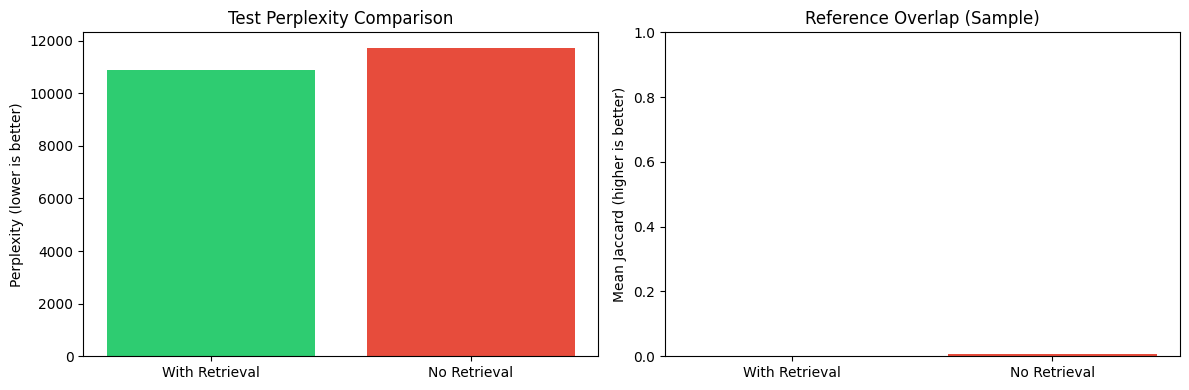

Saved ablation report to results/partC_rag_ablation_study.json
Saved ablation plot to results/partC_rag_ablation_study.png


In [38]:
# RAG ablation study: compare decoder performance with and without retrieval context

# Compute perplexity in both settings
nll_with_ret, ppl_with_ret = run_epoch(partC_test_loader, train=False)
nll_no_ret, ppl_no_ret = run_epoch(partC_test_no_ret_loader, train=False)

# Lightweight lexical overlap against references for generated outputs

def token_set(text):
    return set(tokenize_text(clean_text(text)))


def jaccard(a, b):
    sa, sb = token_set(a), token_set(b)
    if len(sa | sb) == 0:
        return 0.0
    return len(sa & sb) / len(sa | sb)

sample_eval_indices = [5, 15, 30, 45, 60]
rows = []

for idx in sample_eval_indices:
    full_ex = partC_test_examples[idx]
    base_ex = partC_test_examples_no_retrieval[idx]

    gen_full = generate_explanation(decoder_model, full_ex['prompt'], max_new_tokens=45, temperature=0.8, top_k=30)
    gen_base = generate_explanation(decoder_model, base_ex['prompt'], max_new_tokens=45, temperature=0.8, top_k=30)

    ref = full_ex['target']
    rows.append({
        'idx': int(idx),
        'jaccard_full': float(jaccard(gen_full, ref)),
        'jaccard_baseline': float(jaccard(gen_base, ref)),
    })

ablation_df = pd.DataFrame(rows)
mean_jaccard_full = float(ablation_df['jaccard_full'].mean())
mean_jaccard_baseline = float(ablation_df['jaccard_baseline'].mean())

print("\n" + "=" * 80)
print("RAG ABLATION STUDY")
print("=" * 80)
print(f"Perplexity with retrieval context:    {ppl_with_ret:.2f}")
print(f"Perplexity without retrieval context: {ppl_no_ret:.2f}")
print(f"Relative PPL change (%): {((ppl_no_ret - ppl_with_ret) / max(ppl_with_ret, 1e-9)) * 100:.2f}")
print("\nJaccard overlap with references on sample generations:")
print(ablation_df.to_string(index=False))
print(f"Mean Jaccard (with retrieval): {mean_jaccard_full:.4f}")
print(f"Mean Jaccard (baseline):       {mean_jaccard_baseline:.4f}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(['With Retrieval', 'No Retrieval'], [ppl_with_ret, ppl_no_ret], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Test Perplexity Comparison')
axes[0].set_ylabel('Perplexity (lower is better)')

axes[1].bar(['With Retrieval', 'No Retrieval'], [mean_jaccard_full, mean_jaccard_baseline], color=['#2ecc71', '#e74c3c'])
axes[1].set_title('Reference Overlap (Sample)')
axes[1].set_ylabel('Mean Jaccard (higher is better)')
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('results/partC_rag_ablation_study.png', dpi=300, bbox_inches='tight')
plt.show()

ablation_results = {
    'with_retrieval': {
        'test_nll': float(nll_with_ret),
        'test_perplexity': float(ppl_with_ret),
        'mean_jaccard_sample': mean_jaccard_full,
    },
    'without_retrieval': {
        'test_nll': float(nll_no_ret),
        'test_perplexity': float(ppl_no_ret),
        'mean_jaccard_sample': mean_jaccard_baseline,
    },
    'delta': {
        'perplexity_change_percent': float(((ppl_no_ret - ppl_with_ret) / max(ppl_with_ret, 1e-9)) * 100),
        'jaccard_change': float(mean_jaccard_full - mean_jaccard_baseline),
    },
}

with open('results/partC_rag_ablation_study.json', 'w') as f:
    json.dump(ablation_results, f, indent=2)

print("Saved ablation report to results/partC_rag_ablation_study.json")
print("Saved ablation plot to results/partC_rag_ablation_study.png")








## Overall Evaluation Rubric


Part A: Encoder Model 25 

Part B: Retrieval Module 15 

Part C: Decoder & RAG Pipeline 25 

Report Quality 10 Clarity, analysis, depth (3–5  pages)

GitHub & Incremental Commits 5 

Version control discipline

TOTAL 80

Bonus: UI / Visualization OR advanced features Up to 5 

Final mark capped at 80









Note: The total marks for this assignment are 80 marks. The bonus of up to 5 marks is awarded  on top of already earned marks and the final recorded mark will not exceed 80. 

Deliverables 

• Complete, well-commented source code submitted as a Jupyter Notebook 

• Trained model weights saved in the models/ directory 

• Saved encoder embeddings for the training set in the results/ directory 

• Report (3–5 pages) covering all items listed below 

Report Must Cover: 

• Overall system design and methodology 

• Justification of design decisions for each part 

• Preprocessing pipeline description 

• Evaluation results with tables and plots for all metrics 

• Hyperparameter tuning log with analysis of results 

• RAG ablation study comparing the system with and without retrieval 



All code must be properly organised and runnable from top to bottom. Clear instructions for  execution must be provided at the top of the notebook. 

Submission Requirements 

Required Directory Structure 

Directory 

Contents

results/ 

Saved model metrics and evaluation outputs

models/ 

Trained model weights

